# Modeling Power Outages by County in Maine

The goal of this notebook is to use sktime to predict customers.out in the counties in Maine.

Maine has only sixteen counties with a wide range of topography and population. 
If we are able to set up hierarchical methods for ME, we should be able to scale up to the entire US.

The outline of the notebook is:
- Setup
    - Import packages
    - Load and arrange the data
    - Set the y-variable
- EDA
    - Graph customers.out as time series for each county
    - Make ACF graphs for each county to identify potential seasonality
    - Check for stationarity
    - Make PACF graphs to suggest model order
- Analysis: SARIMAX with a sliding window
    - Set up features
    - Set up ARIMA forecaster
    - Trying the evaluate method
    - Plotting values from first split
    - Examine predictions and scoring
    - Plot the train and test windows
    - Manual evaluation (alternative to "evaluate" method)
- XGBoost
    - The structure of this section mirrors the previous section

## SKTime Guides

The basic sktime workflow is:
1. Preparation of the data
2. Specification of the time points for which forecasts are requested. This uses a numpy.array or the ForecastingHorizon object.
3. Specification and instantiation of the forecaster. This follows a scikit-learn-like syntax; forecaster objects follow the familiar scikit-learn BaseEstimator interface.
4. Fitting the forecaster to the data, using the forecaster's fit method
5. Making a forecast, using the forecaster's predict method

Following guides at:
- https://github.com/sktime/sktime/blob/main/examples/01_forecasting.ipynb
- https://www.sktime.net/en/latest/examples/01c_forecasting_hierarchical_global.html

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sktime.utils.plotting import plot_series

from sktime.split import temporal_train_test_split
from sktime.split import SlidingWindowSplitter

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.sarimax import SARIMAX
from sktime.forecasting.compose import ForecastingPipeline
from sktime.forecasting.model_evaluation import evaluate

# Note that we'll need to install darts for xgb to work:
# conda install -c conda-forge -c pytorch u8darts-all
from sktime.forecasting.darts import DartsXGBModel

from sklearn.preprocessing import StandardScaler

from sktime.transformations.series.adapt import TabularToSeriesAdaptor

from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.performance_metrics.forecasting import MeanSquaredError

# There is a futurewarning from sklearn that will be addressed eventually in sktime; suppressing it for now.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Load and Arrange the Data

We'll load the dataset with eaglei, noaa, era5, county-level, and engineered variables

We'll restrict to our training set (pre-2022)

For now, we'll also restrict ourselves to Maine, which has just 16 counties--a sufficient number to let us try out the techniques before deploying on the entire country

In [2]:
#Load the engineered data
df = pd.read_parquet('../Data/Merged_Data/eaglei_noaa_era5_engineered.parquet')

In [3]:
# Sort df
df = df.sort_values(by=['fips_code', 'datetime'])

# Restrict df to years prior to 2022
# For now, we'll just focus on Maine
df = df[df['STUSPS'] == 'ME']
df = df[df['YEAR'] < 2022]

# The first nonzero entry for customers_out in Maine was November 2nd, 2014
df = df[df['datetime'] > '2014-11-01']

# Use fips_code and datetime as indices
df = df.set_index(['fips_code', 'datetime'])

#Sort df
#df = df.sort_index()

## Set the y-variable (customers_out)

We'll need to do a bit of work with the index to make it compatible with sktime.
Specifically, we'll need to recreate the multiindex and imbue it with a frequency

In [4]:
y = df['customers_out']

#Set the multiindex on y
y = y.reset_index()

#Use fips_code and datetime as a multiindex on y
y = y.set_index(['fips_code', 'datetime'])

#Sort y
y = y.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)

## Set the y-variable (max customers out) as the maximum of the next four 6-hour intervals

### QUESTION: Is "looking into the future" okay? Or should we forecast the underlying variable and use a custom loss function?

In [ ]:
# Compute a new variable that is the maximum value of customers_out over the next four times
df['customers_out_max'] = df.groupby('fips_code')['customers_out'].rolling(4).max().reset_index(level=0, drop=True)

# Drop rows from df with NaN
df = df.dropna()

y = df['customers_out_max']

#Set the multiindex on y
y = y.reset_index()

#Use fips_code and datetime as a multiindex on y
y = y.set_index(['fips_code', 'datetime'])

#Sort y
y = y.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)

# EDA

## Graphing the Data

We'll start by making some plots of the data to get a sense of the sparsity of the data

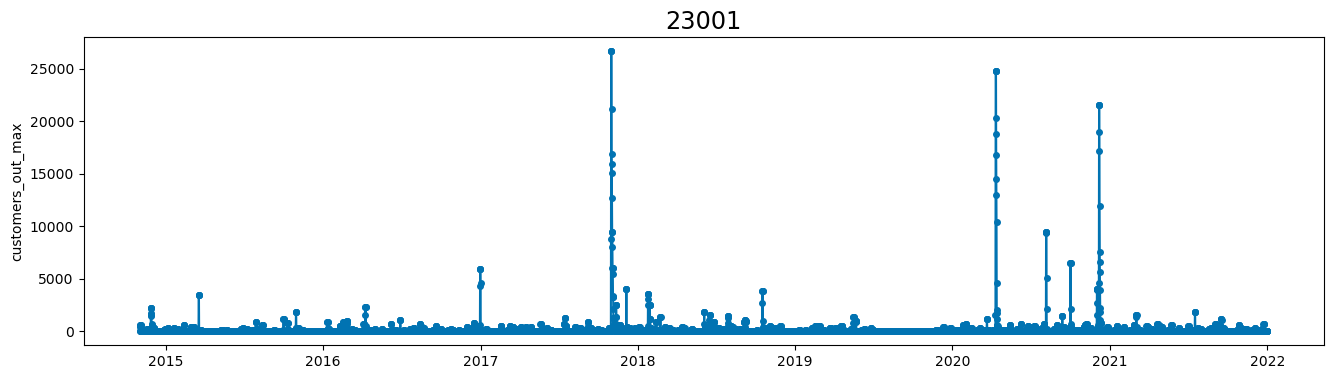

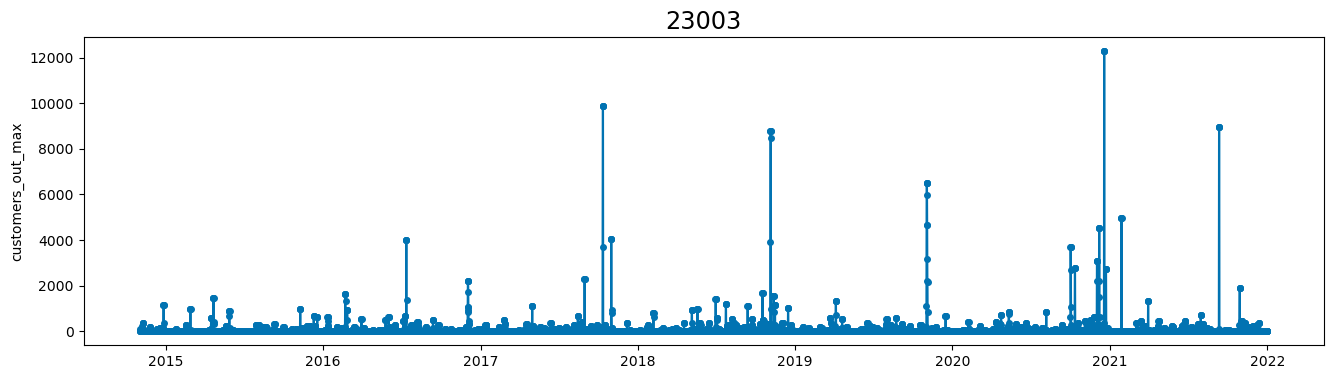

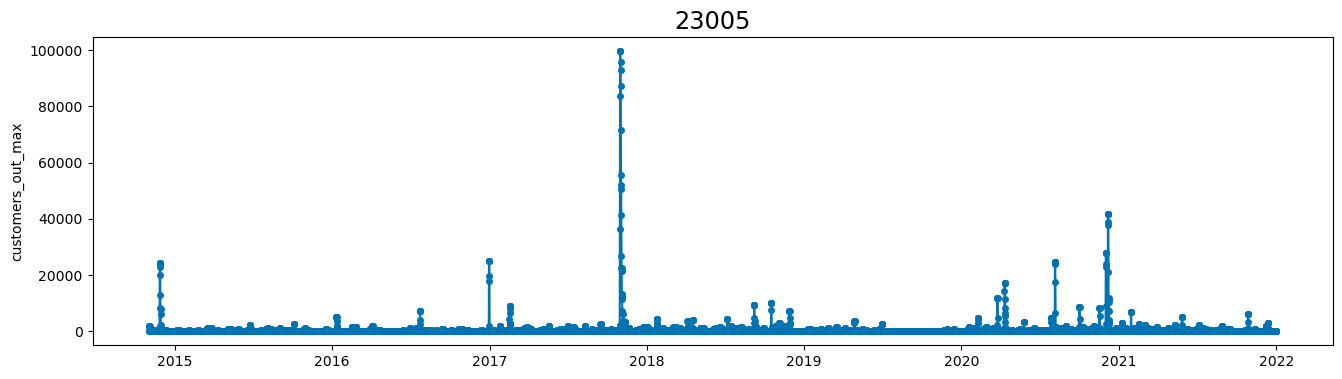

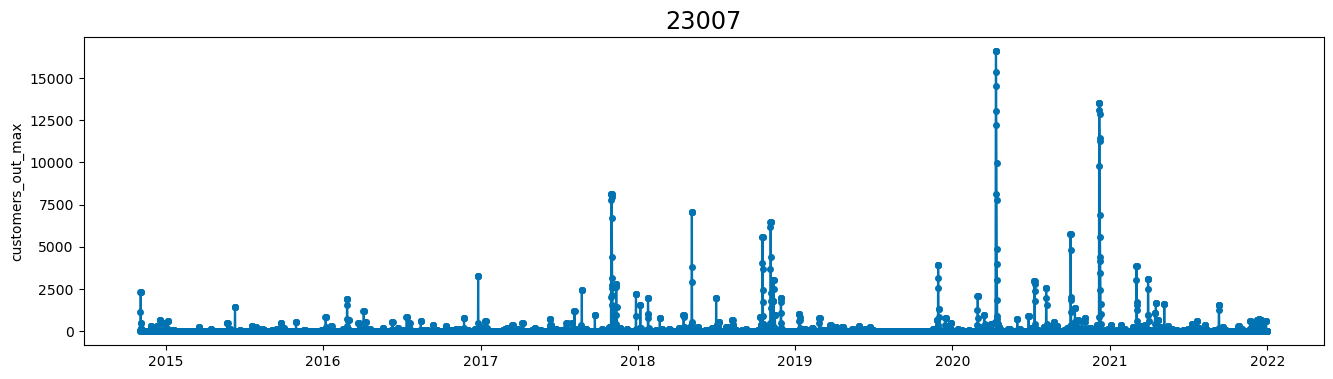

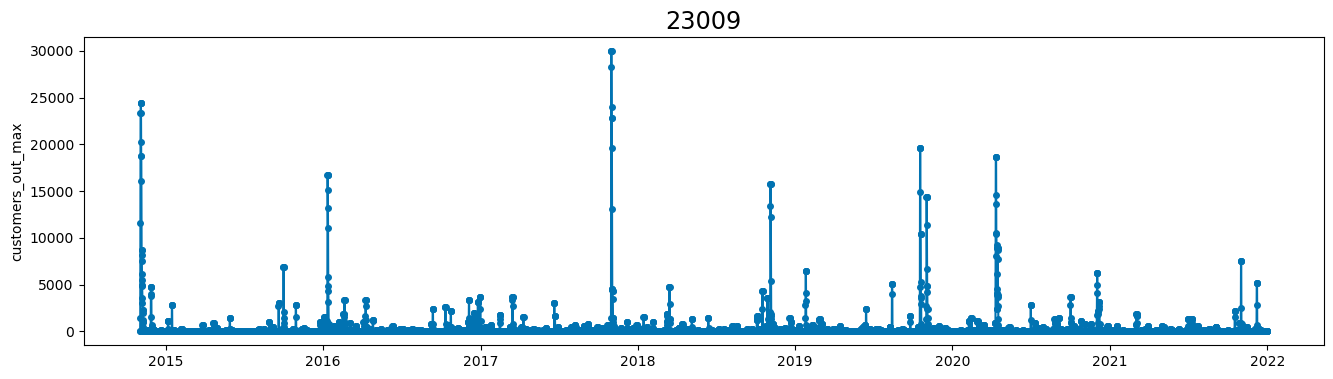

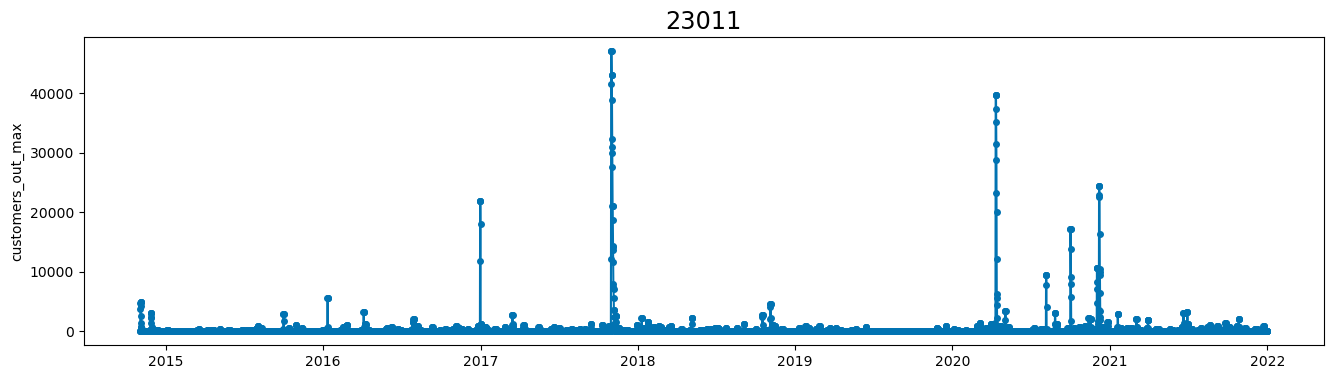

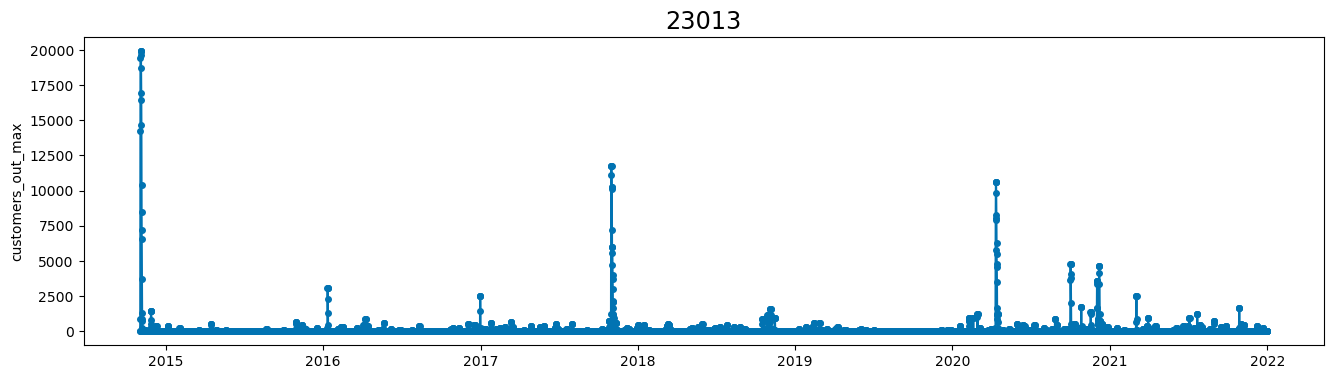

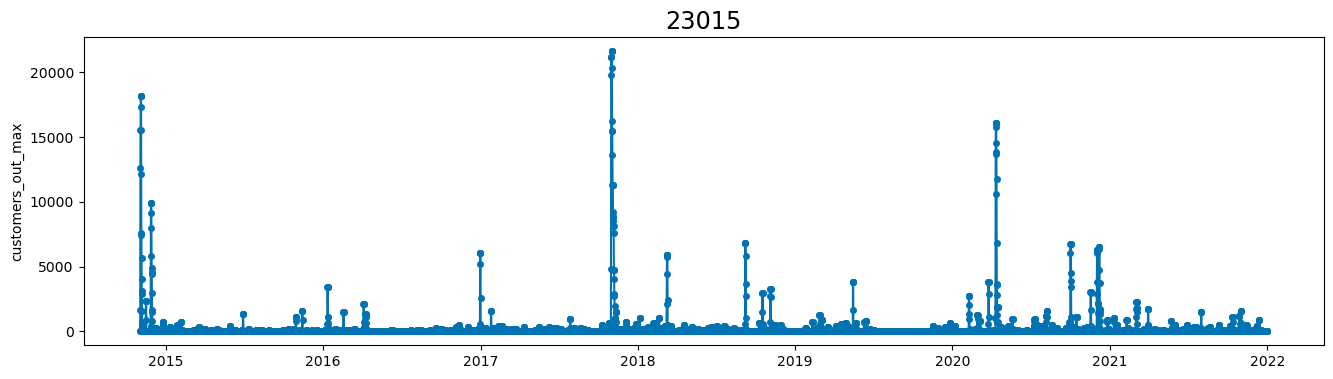

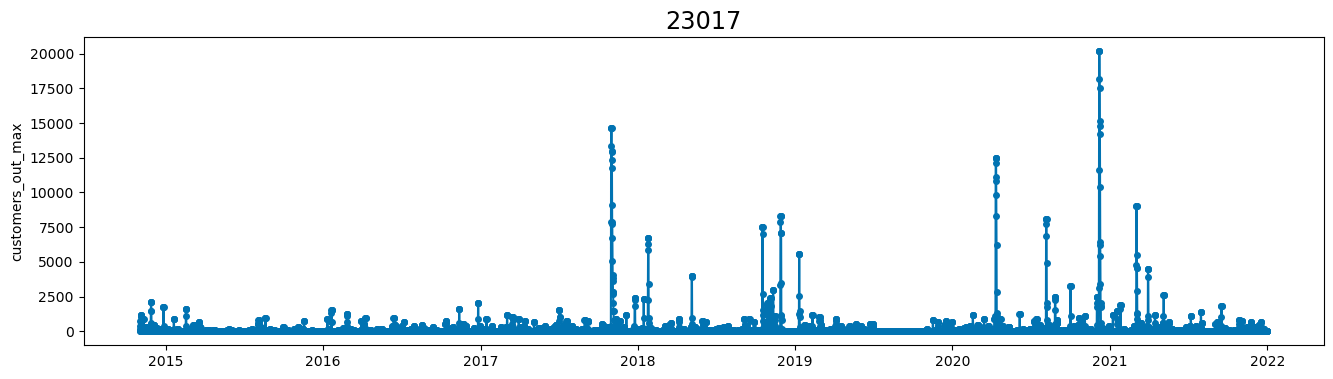

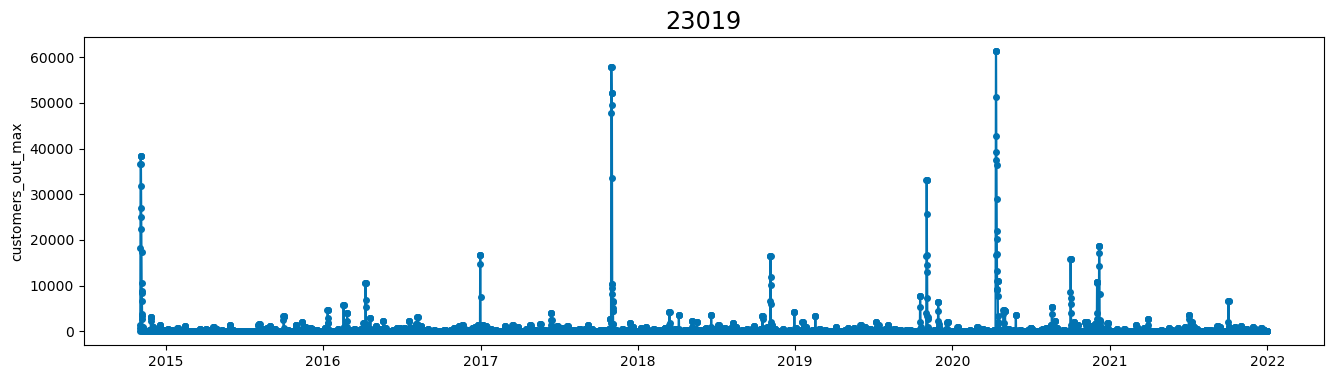

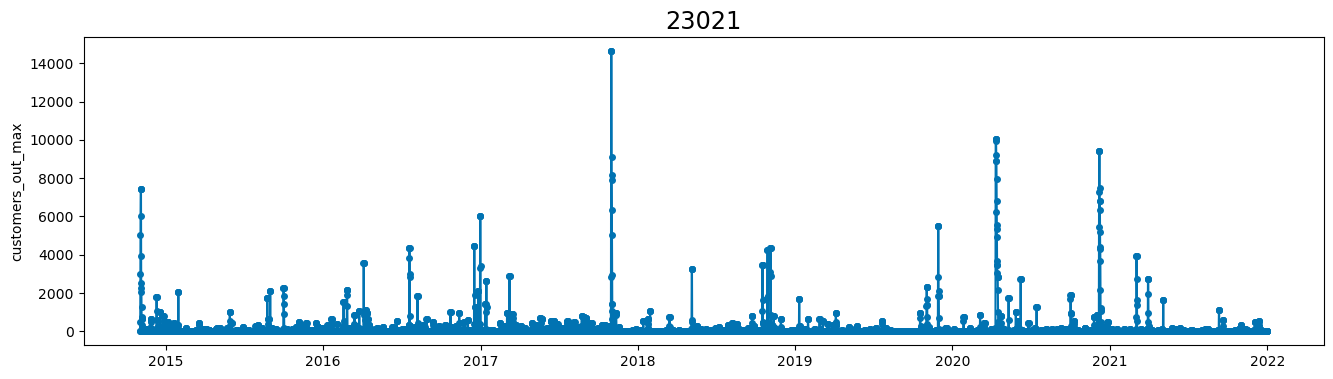

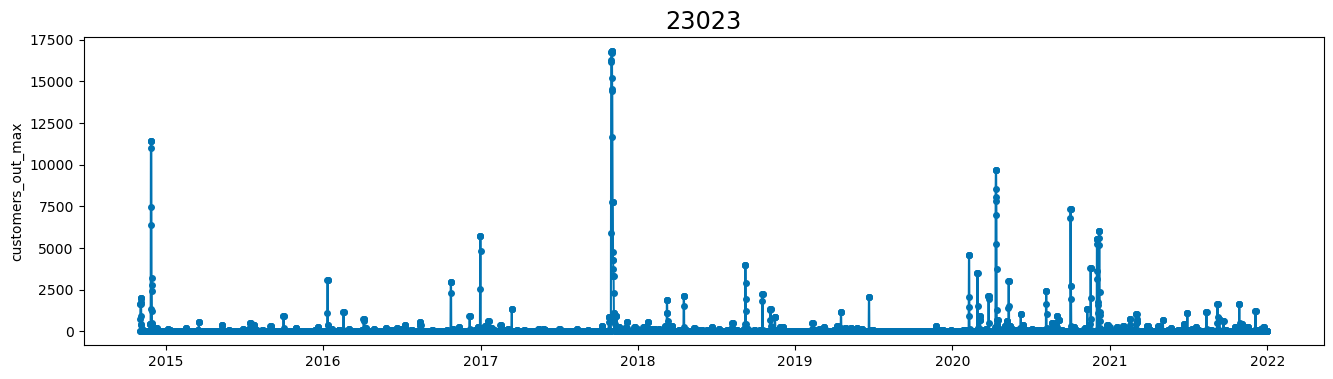

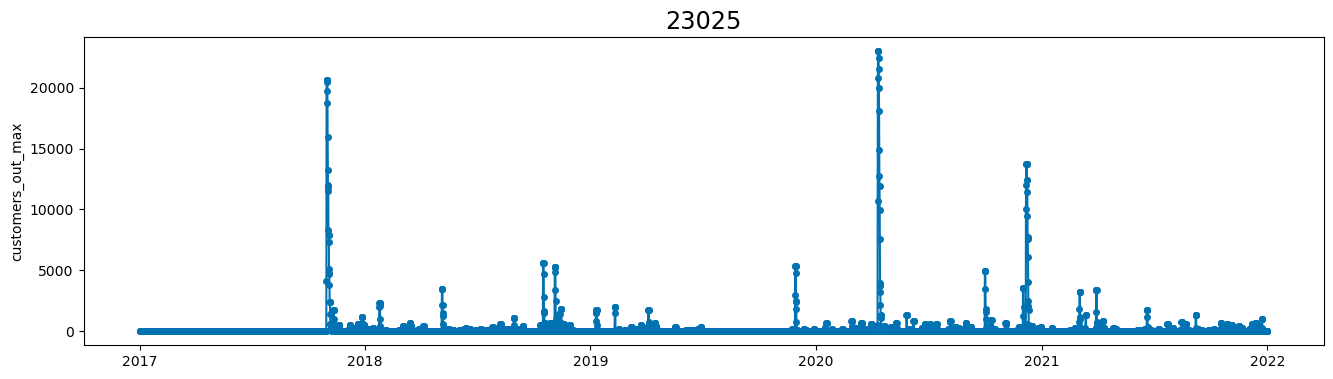

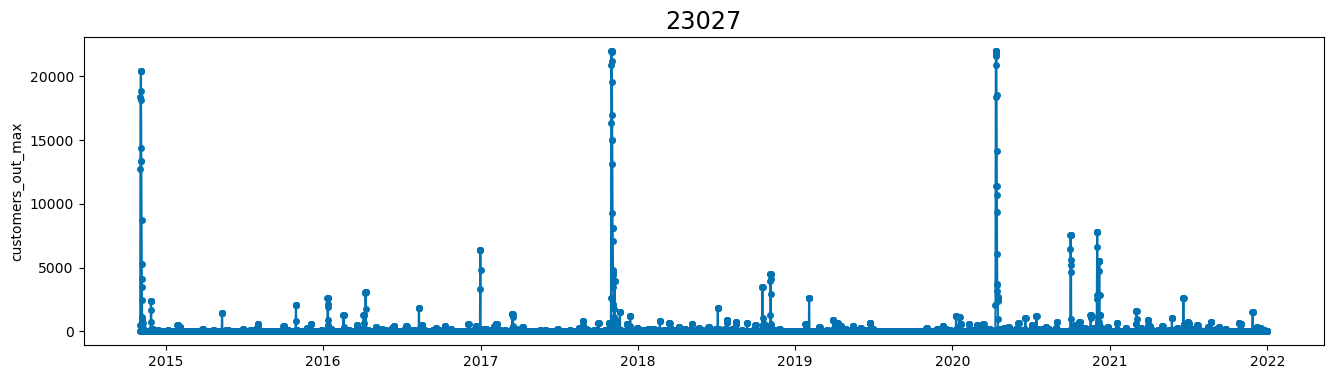

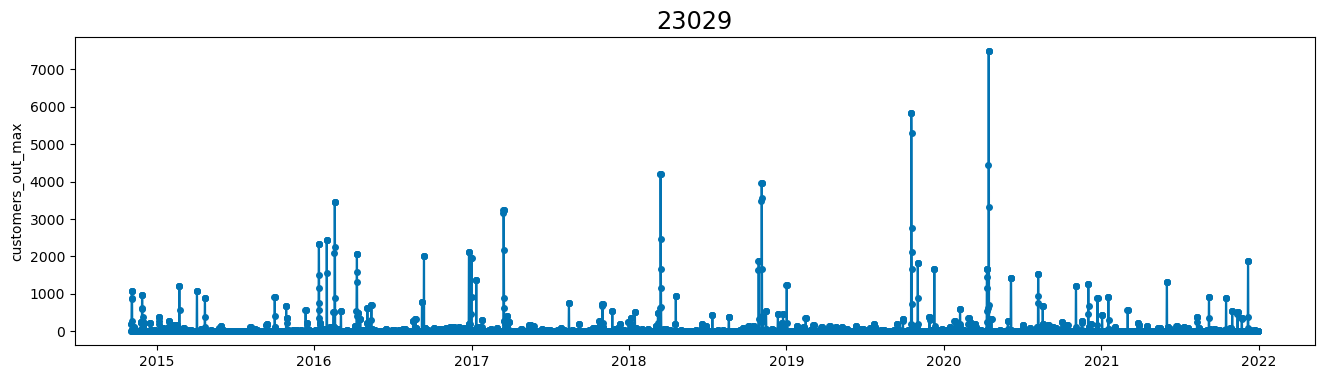

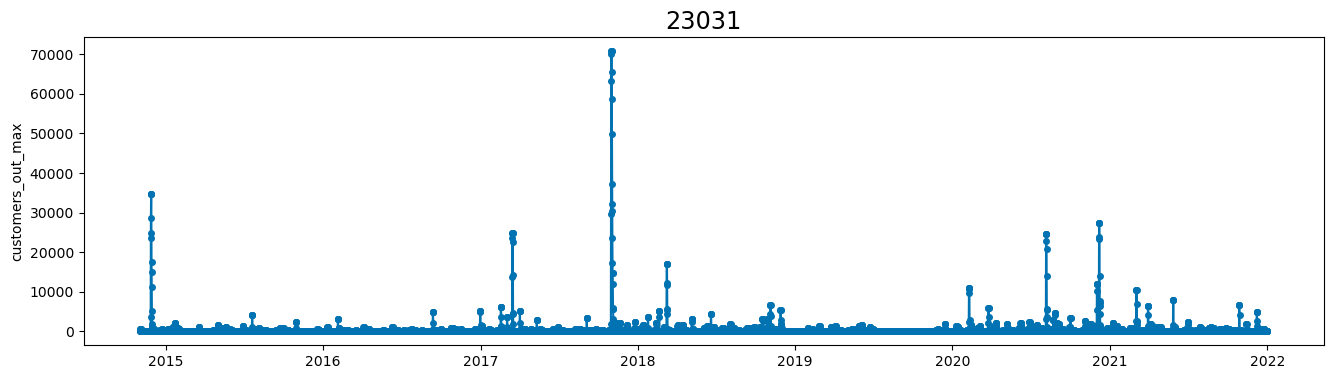

In [9]:
#For each value of fips_code, plot the value of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    plot_series(y_fips, title=fips_code)

## ACF, Stationarity, and PACF plots

We'll make an autocorrelation and partial autocorrelation plot for each of the counties.

The ACF plots suggest that there are correlations with up to 15-20 lags, which corresponds to 4-5 days. There doesn't appear to be any consistent seasonality.

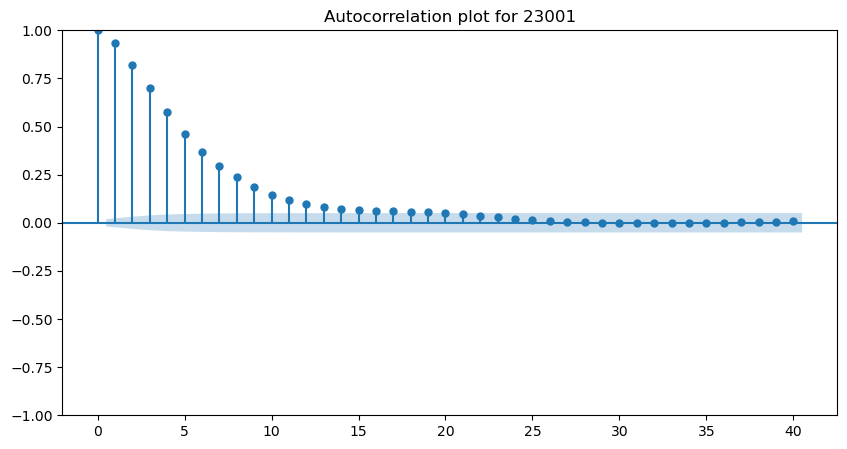

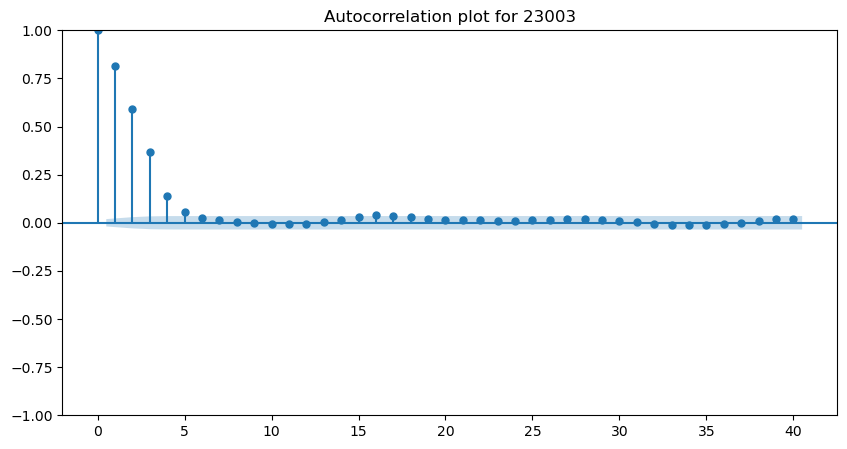

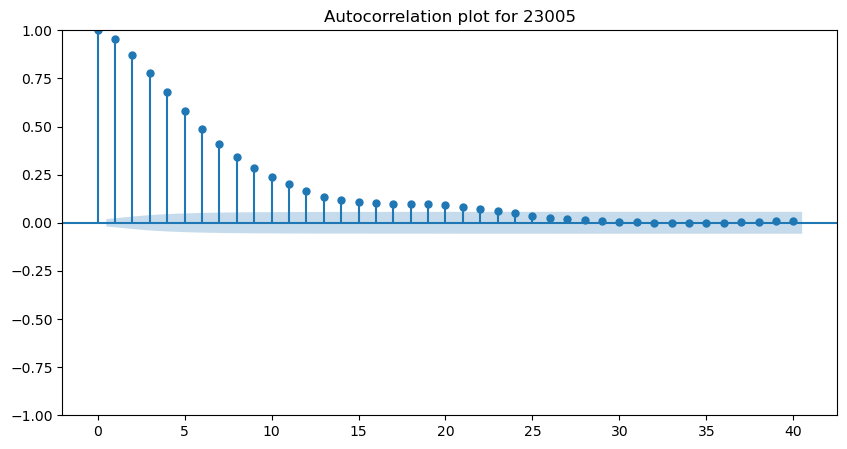

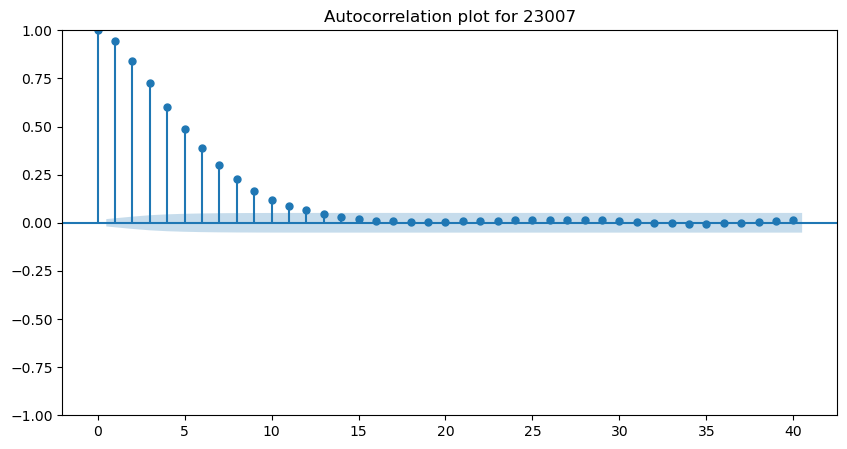

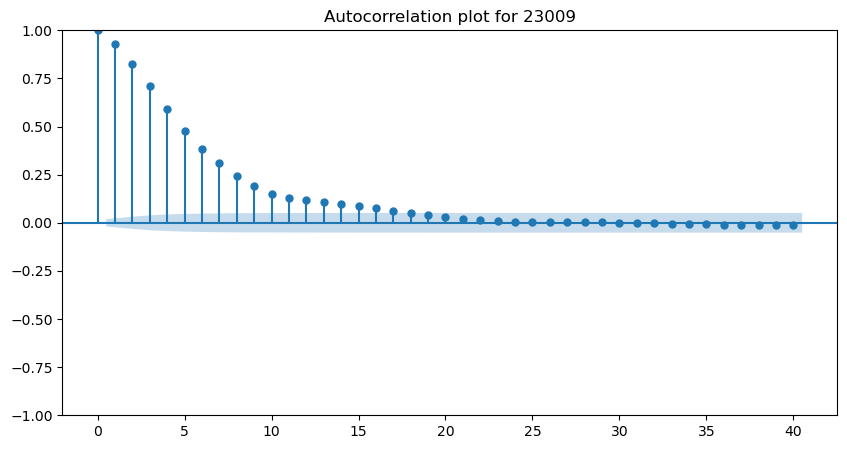

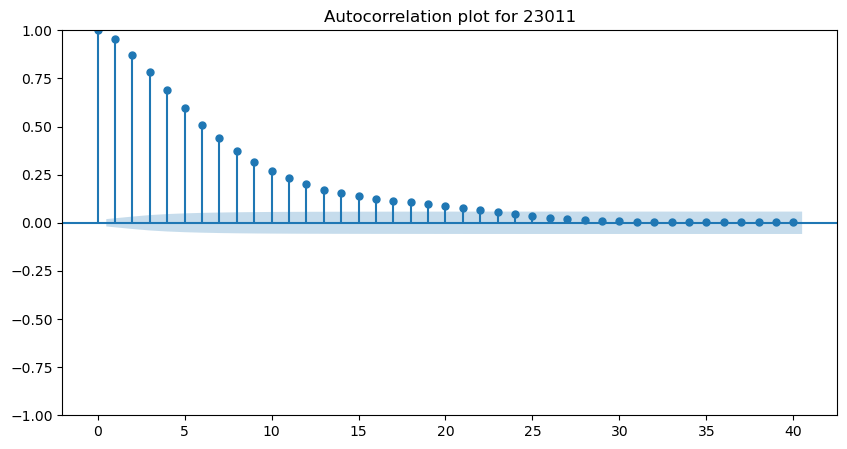

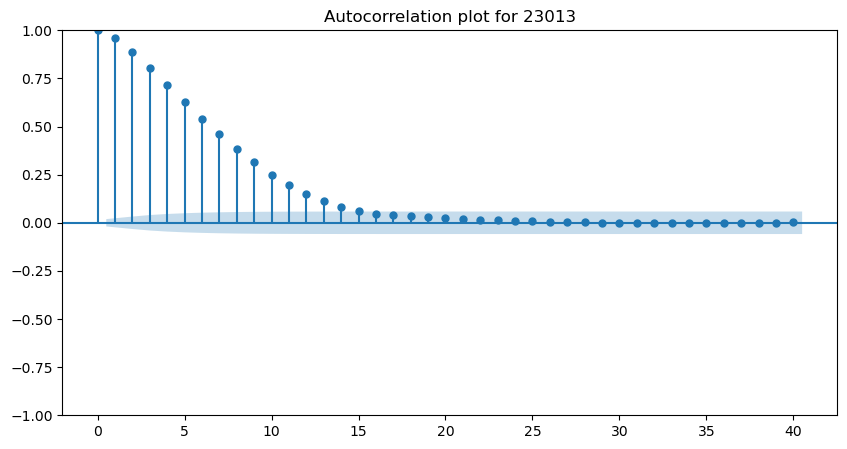

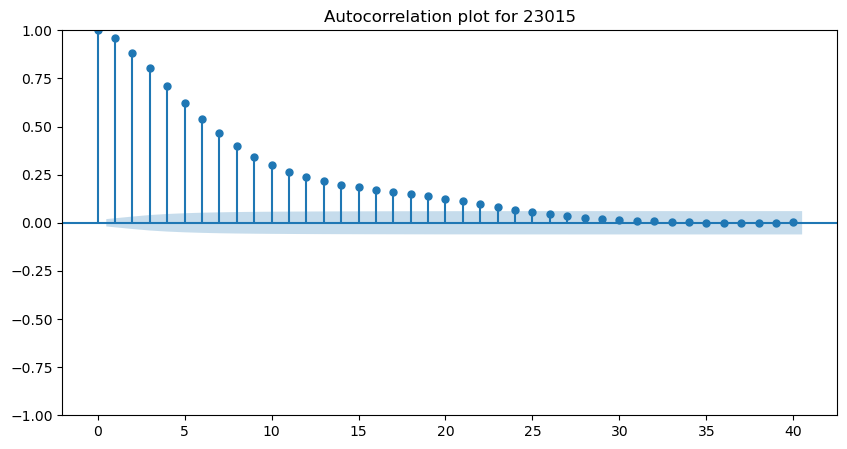

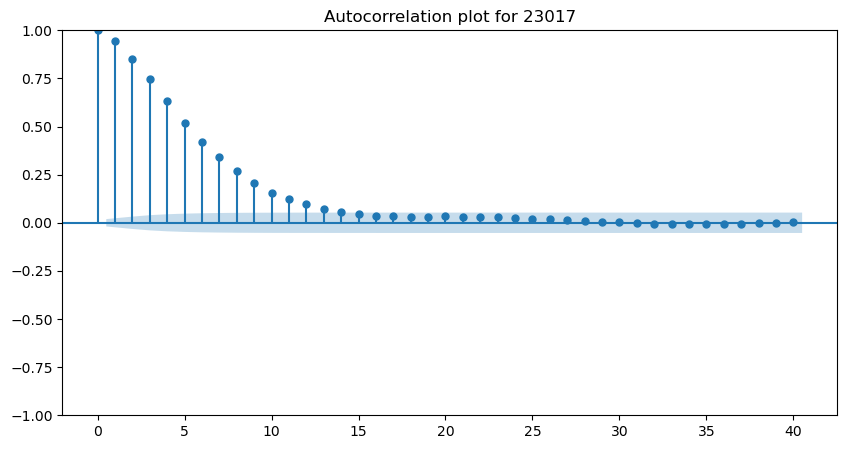

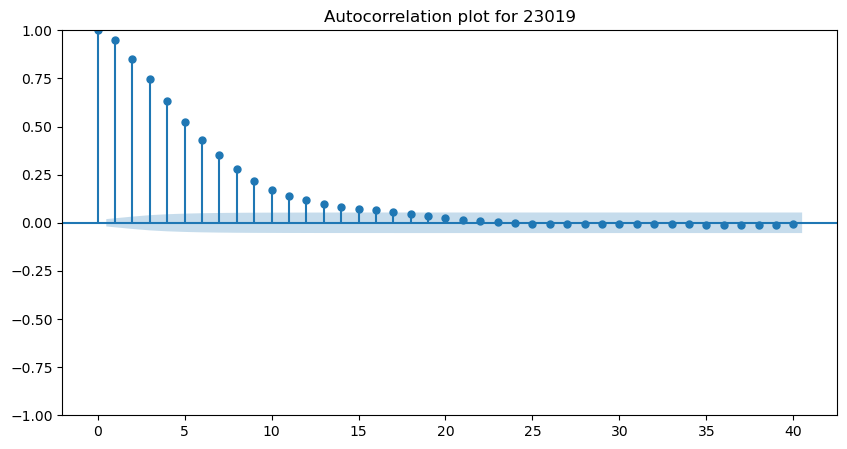

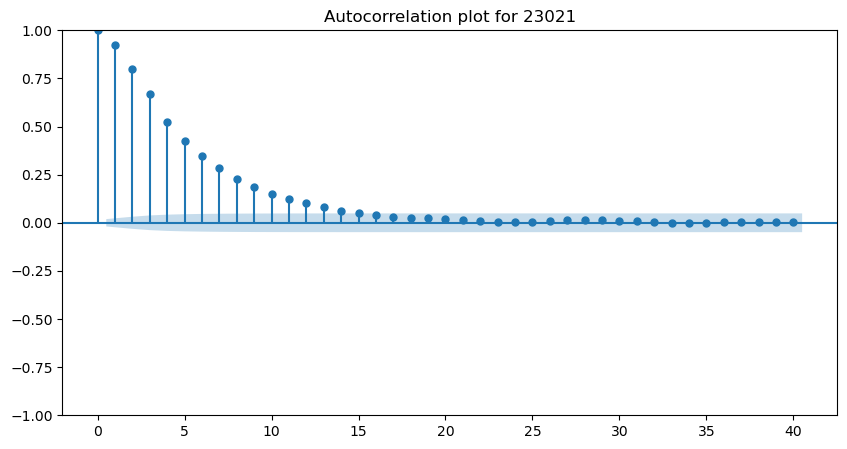

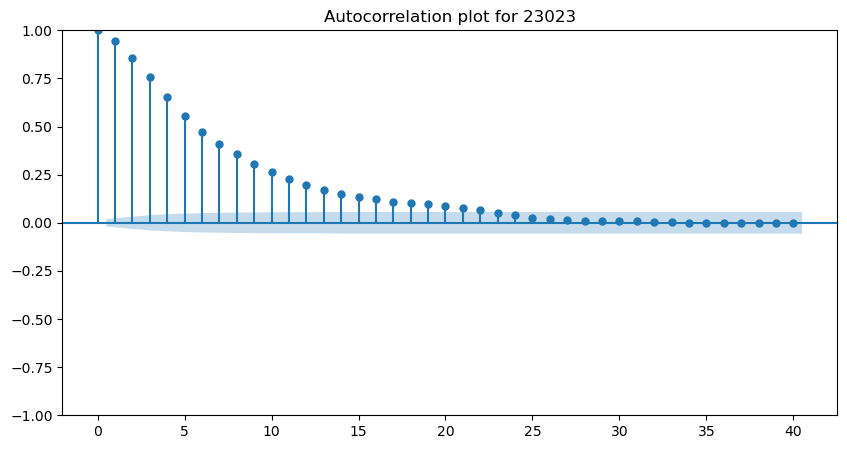

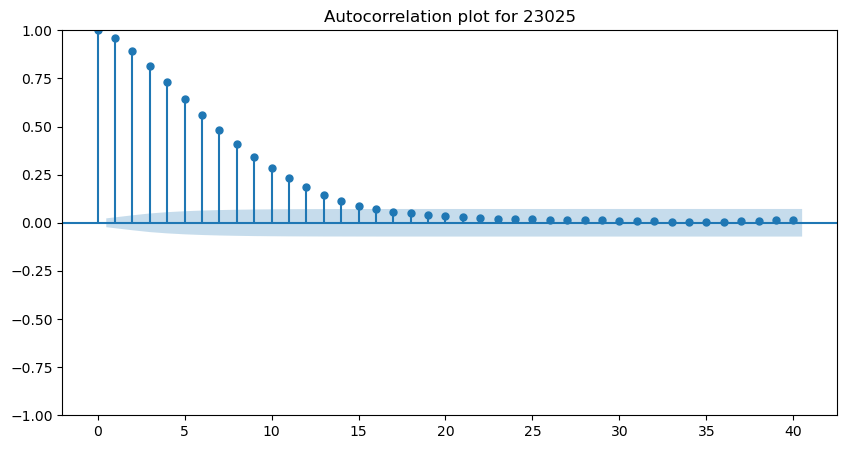

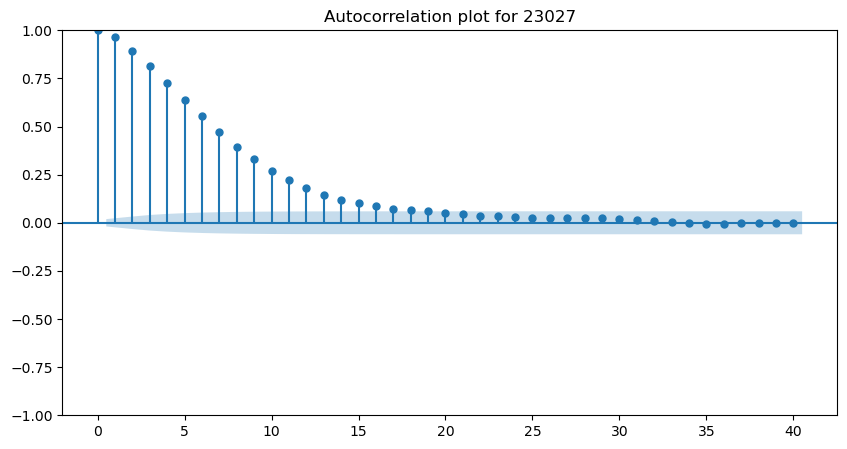

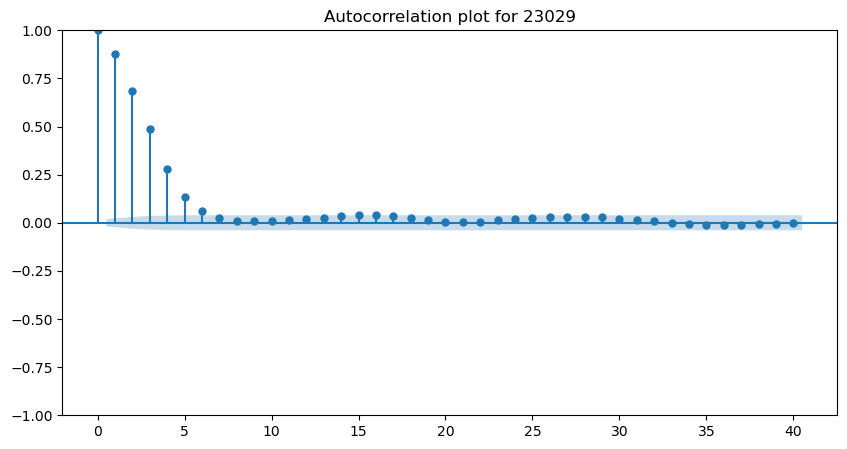

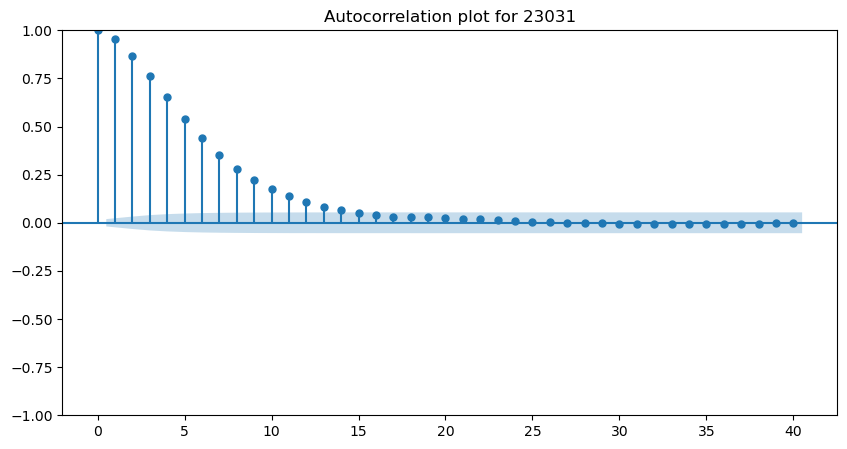

In [11]:
#For each value of fips_code use statsmodels to make an autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sm.graphics.tsa.plot_acf(y_fips['customers_out_max'], lags=40, ax=ax)
    plt.title(f'Autocorrelation plot for {fips_code}')
    plt.show()

### Testing for stationarity

We'll use an augmented Dickey-Fuller test. All the p-values are quite tiny, suggesting stationarity.

This suggests that an autoregressive model is appropriate.

In [12]:
# Create a numpy array to hold the fips_codes and p-values
p_values = np.zeros((16, 2))
i=0

#For each value of fips_code, run the Augmented Dickey-Fuller test
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    result = sm.tsa.stattools.adfuller(y_fips['customers_out_max'])
    p_values[i,0]=int(fips_code)
    p_values[i,1]=result[1]
    i=i+1
p_values

array([[2.30010000e+04, 3.23266551e-30],
       [2.30030000e+04, 0.00000000e+00],
       [2.30050000e+04, 1.42607925e-28],
       [2.30070000e+04, 0.00000000e+00],
       [2.30090000e+04, 0.00000000e+00],
       [2.30110000e+04, 1.16547618e-29],
       [2.30130000e+04, 0.00000000e+00],
       [2.30150000e+04, 1.56125475e-28],
       [2.30170000e+04, 0.00000000e+00],
       [2.30190000e+04, 2.03069952e-30],
       [2.30210000e+04, 5.32009487e-30],
       [2.30230000e+04, 4.09893374e-30],
       [2.30250000e+04, 3.11535542e-28],
       [2.30270000e+04, 5.61258284e-27],
       [2.30290000e+04, 0.00000000e+00],
       [2.30310000e+04, 2.21620086e-30]])

### PACF Plots

There is quite a bit of variation from county to county. The first and second lags are statistically significant for all counties. It isn't uncommon for the fourth and fith lags to also be statistically significant. 

This suggests we might use a fifth-order autoregressive model.

### Question: Is that right???

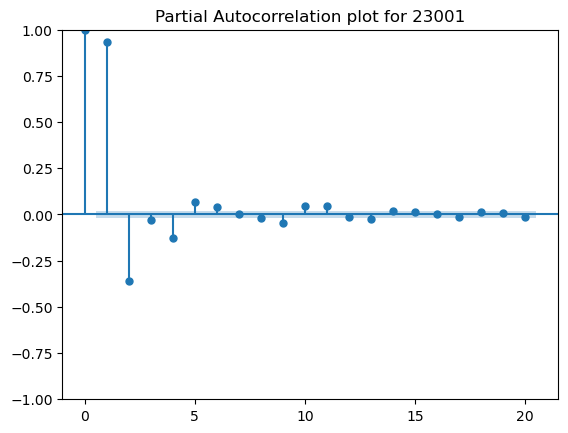

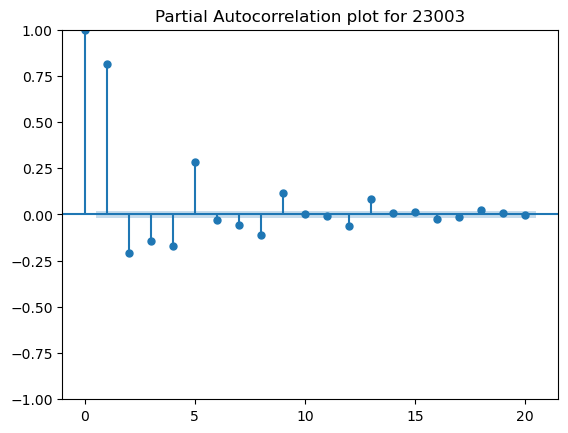

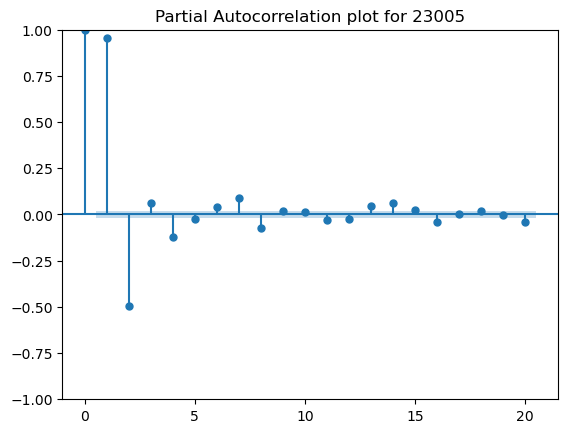

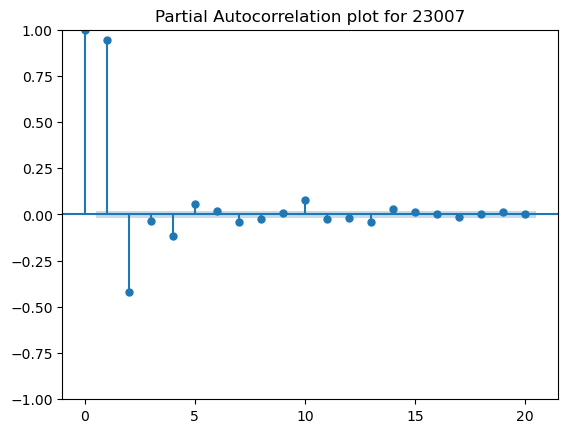

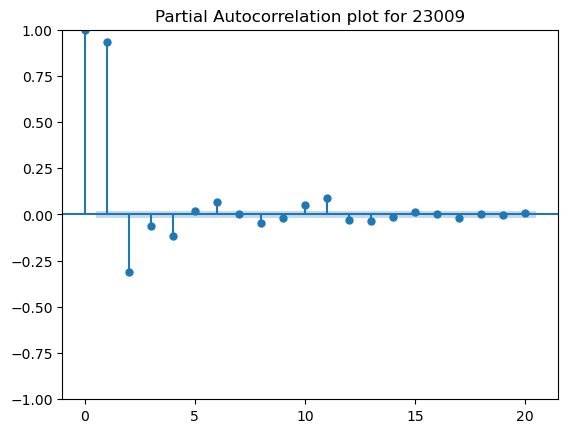

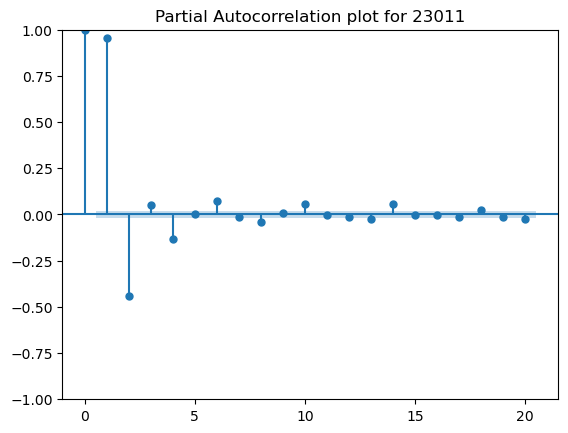

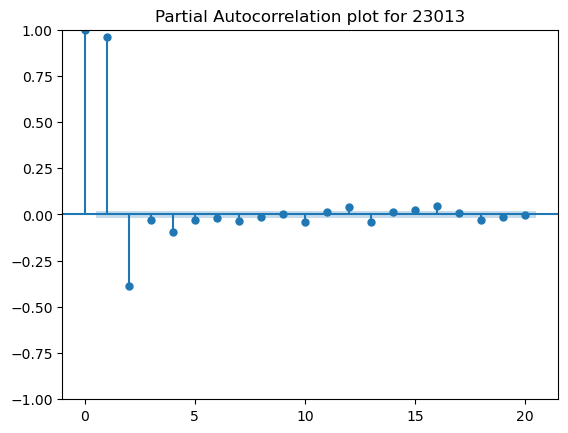

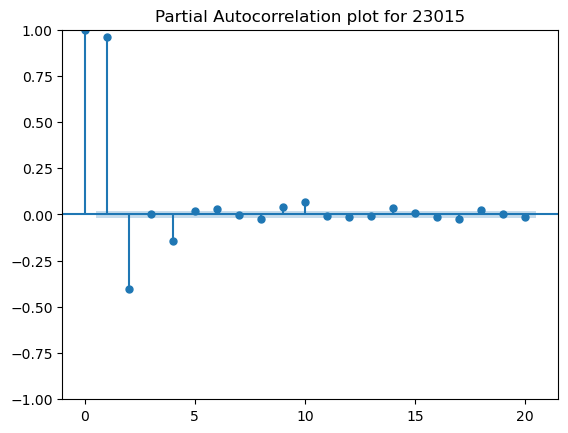

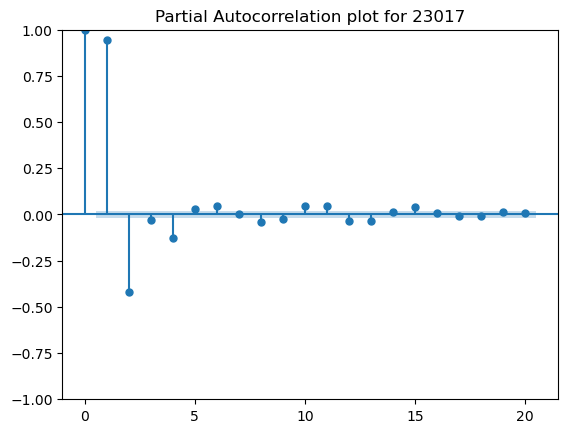

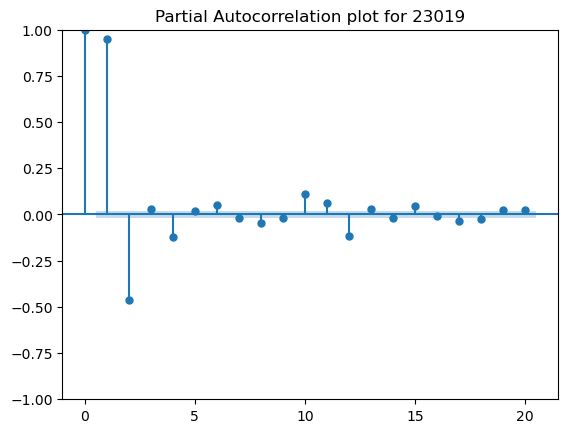

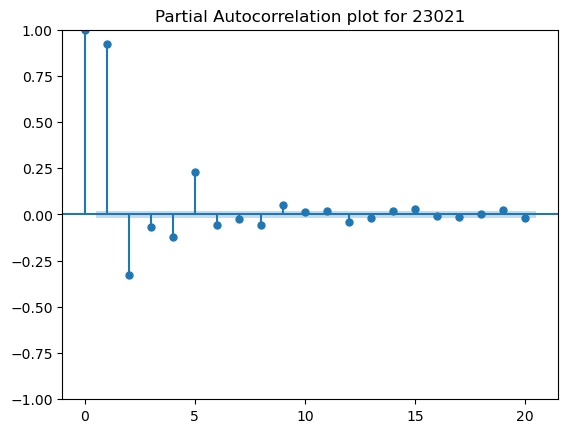

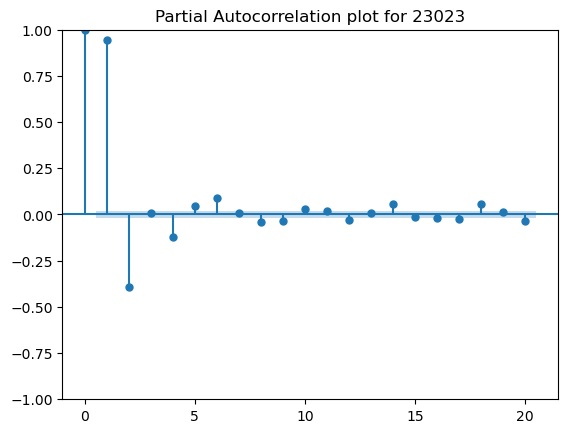

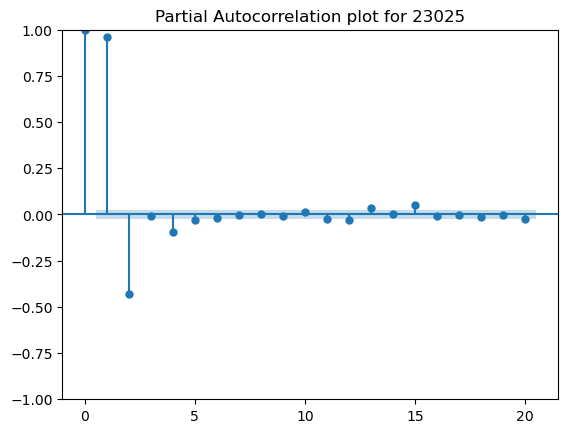

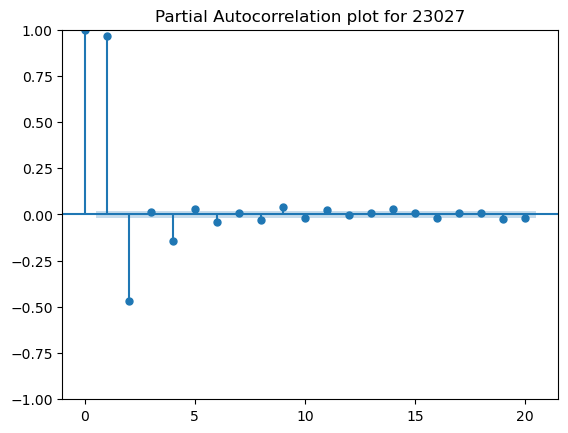

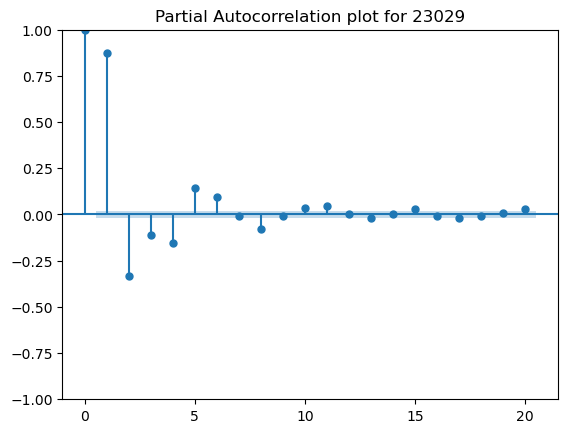

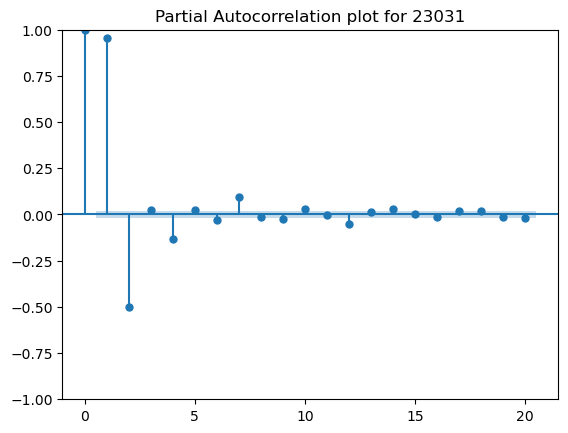

In [13]:
#For each value of fips_code make a partial autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    sm.graphics.tsa.plot_pacf(y_fips, lags=20, method='ols')
    plt.title(f'Partial Autocorrelation plot for {fips_code}')
    plt.show()

### Make a plot of the train and test windows

### QUESTION: What is the relationship between window, forecasting horizon, training set, testing set, cv splits, and what the model uses to make it predictions?

In [19]:
#Sample code from the website

from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_windows(y, train_windows, test_windows, title=""):
    """Visualize training and test windows."""
    simplefilter("ignore", category=UserWarning)

    def get_y(length, split):
        # Create a constant vector based on the split for y-axis."""
        return np.ones(length) * split

    n_splits = len(train_windows)
    n_timepoints = len(y)
    len_test = len(test_windows[0])

    train_color, test_color = sns.color_palette("colorblind")[:2]

    fig, ax = plt.subplots(figsize=plt.figaspect(0.3))

    for i in range(n_splits):
        train = train_windows[i]
        test = test_windows[i]

        ax.plot(
            np.arange(n_timepoints), get_y(n_timepoints, i), marker="o", c="lightgray"
        )
        ax.plot(
            train,
            get_y(len(train), i),
            marker="o",
            c=train_color,
            label="Window",
        )
        ax.plot(
            test,
            get_y(len_test, i),
            marker="o",
            c=test_color,
            label="Forecasting horizon",
        )
    ax.invert_yaxis()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(
        title=title,
        ylabel="Window number",
        xlabel="Time",
        xticklabels=y.index,
    )
    # remove duplicate labels/handles
    handles, labels = ((leg[:2]) for leg in ax.get_legend_handles_labels())
    ax.legend(handles, labels)

    # Some helper code from sktime

def get_windows(y, cv):
    """Generate windows."""
    train_windows = []
    test_windows = []
    for i, (train, test) in enumerate(cv.split(y)):
        train_windows.append(train)
        test_windows.append(test)
    return train_windows, test_windows

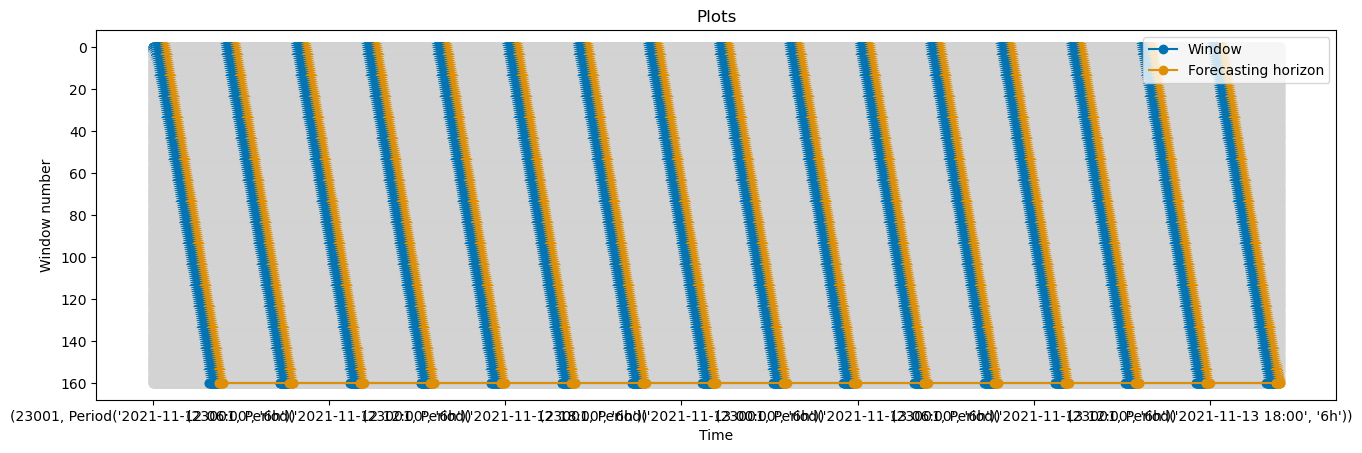

In [20]:
train_windows, test_windows = get_windows(y_small, sw)

plot_windows(y_small, train_windows, test_windows, title="Plots")

# Prediction with exogenous variables

## Set up the features and data


### QUESTION: Can we include non-time-series predictors here?

In [ ]:
# Create a new variable dividing POPULATION divided by AREA
df['density'] = df['POPULATION'] / df['AREA']

# Note: Not currently including Subregion b/c we'd need to convert to a dummy variable

features = ['Pct_Buried_Lines','centroid_longitude','centroid_latitude','density',
       'event_count SnowIce',
       'event_count Flood', 'event_count Storm', 'event_count Hurricane',
       'event_count Heat', 'event_count Fire', 'event_count Wind',
       'event_count Ocean', 'event_count Other', 't2m', 'sf', 'tp', 't2m_mean',
       't2m_max', 'sf_mean', 'sf_max', 'tp_mean', 'tp_max', 'wind_speed',
       'neighbor_mean_wind_speed', 'neighbor_max_wind_speed', 'sf_12h',
       'sf_24h', 'tp_12h', 'tp_24h']

y = df['customers_out_max']
X = df[features]


#Set the multiindex on y and X
y = y.reset_index()
X = X.reset_index()

#Use fips_code and datetime as a multiindex
y = y.set_index(['fips_code', 'datetime'])
X = X.set_index(['fips_code', 'datetime'])

#Sort
y = y.sort_index()
X = X.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)
X.index = X.index.set_levels(X.index.levels[1].to_period('6h'), level=1)

# Restrict to a smaller data set for testing purposes
y_small = y.groupby(level=0).tail(200)
X_small = X.groupby(level=0).tail(200)

## SARIMAX with a sliding window

### Set up the forecaster and sliding window

### QUESTION: How does the order of the forecaster relate to the window length?
(Also check to make sure that I'm thinking about step_length correctly)

In [28]:
# Set up the SARIMAX forecaster with order 5
forecaster_sarimax =SARIMAX(order=(5, 1, 0), seasonal_order=(0, 0, 0, 0), enforce_stationarity=False, enforce_invertibility=False)

pipe_X = ForecastingPipeline(steps=[
    ("scaler", TabularToSeriesAdaptor(StandardScaler())),
    ("forecaster", forecaster_sarimax),
])

# Let y_small and X_small be the most recent 200 observations of y and X for each value of fips_code
y_small = y.groupby(level=0).tail(200)
X_small = X.groupby(level=0).tail(200)

fh = np.arange(1, 13)   #Forecasting horizon - we'll need this later
#fh = ForecastingHorizon(13, is_relative=False)

# Define the SlidingWindowSplitter
sw = SlidingWindowSplitter(
    window_length=28,       # Length of the training window
    fh = np.arange(1,13),   # Forecasting horizon
    step_length=1)          # Step length between windows

### Evaluate the forecaster

In [29]:
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

results = evaluate(
    forecaster=pipe_X,
    cv=sw,
    y=y_small,
    X=X_small,             # This works with exogeneous variables; predictions are made using predict/predict_proba, or predict_quantiles depending on scoring
    strategy="refit",  # Options are "update" and "refit" (which will reset and fit forecaster via fit), verses updating forecaster via "update"
    scoring=MeanSquaredError(square_root = True),       # None defaults to MeanAbsolutePercentageError(symmetric=True). Options at: https://www.sktime.net/en/stable/api_reference/performance_metrics.html
    return_data=True,   # True means it returns three pd.Series columns for y_train, y_pred, and y_test
    error_score="raise",
    backend=None       # (default is None) Parallelization backend; runs parallel evaluate if specified and strategy="refit"; recommendation to use "dask" or "loky"
)

/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt

### Plot the results vs actuals for the first sliding window

Not very good!

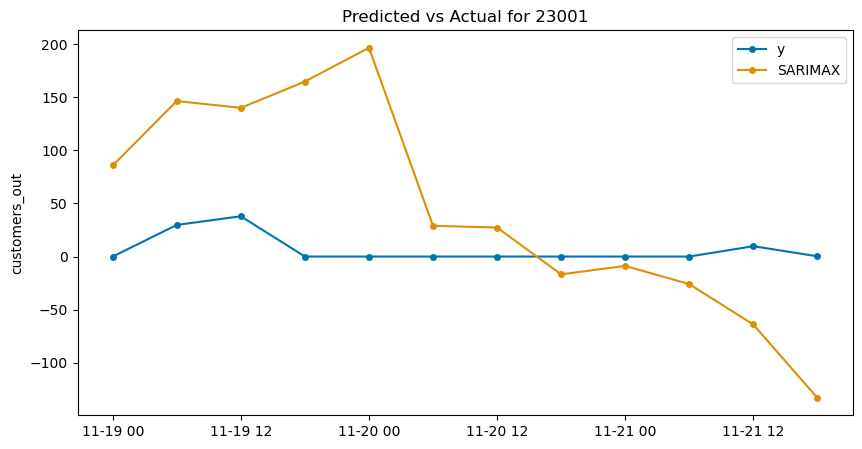

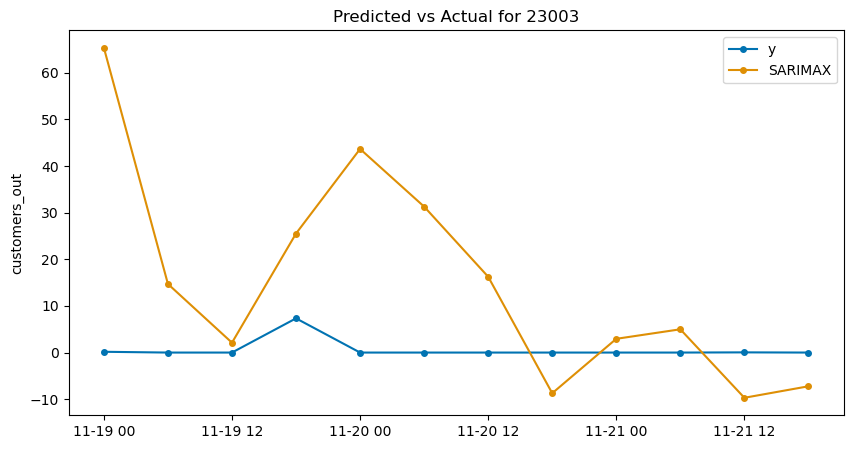

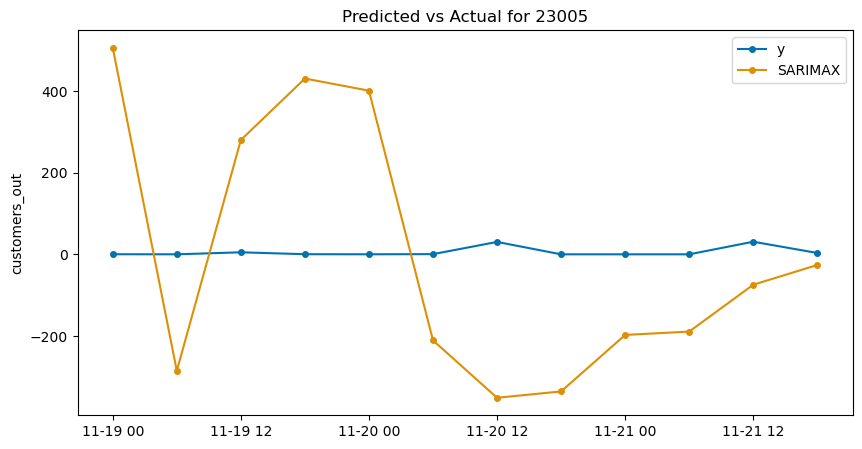

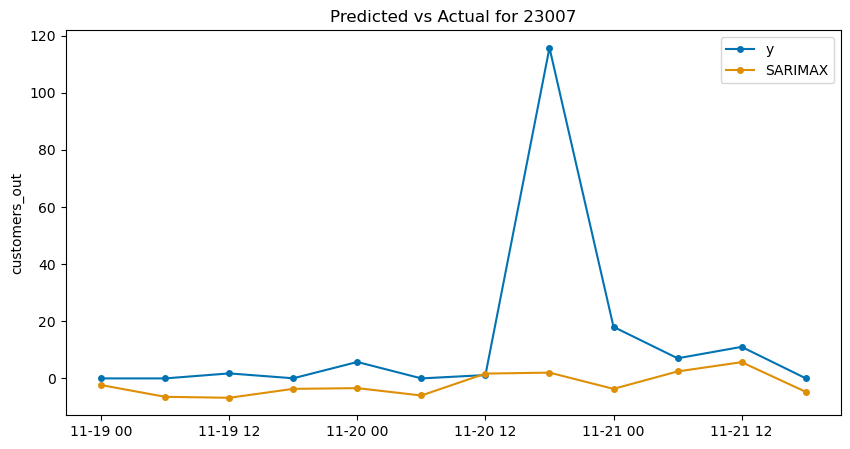

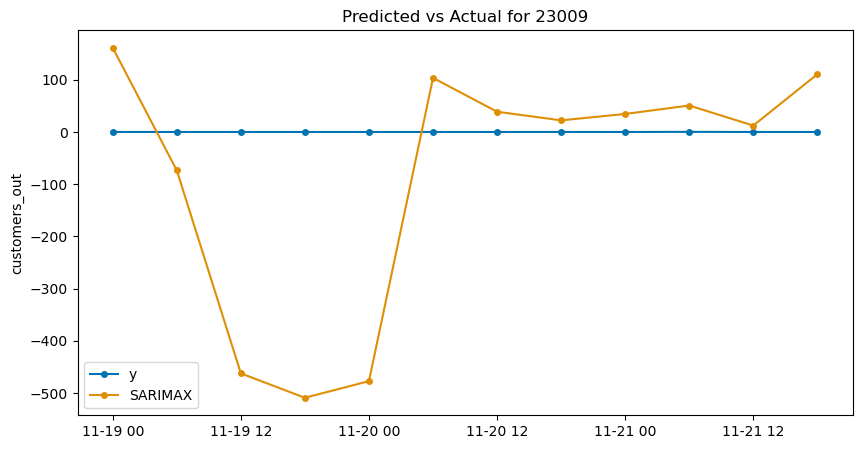

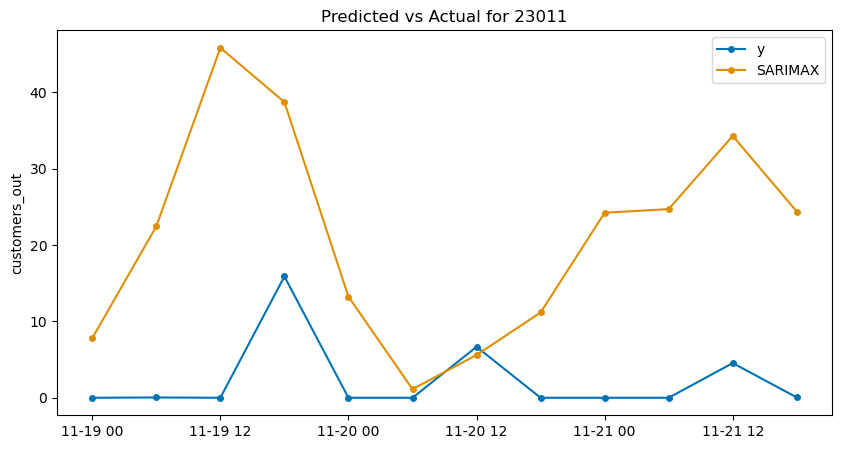

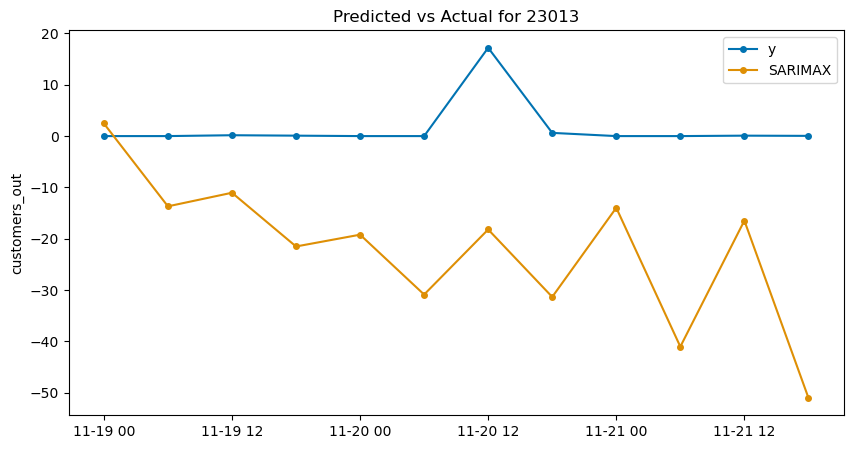

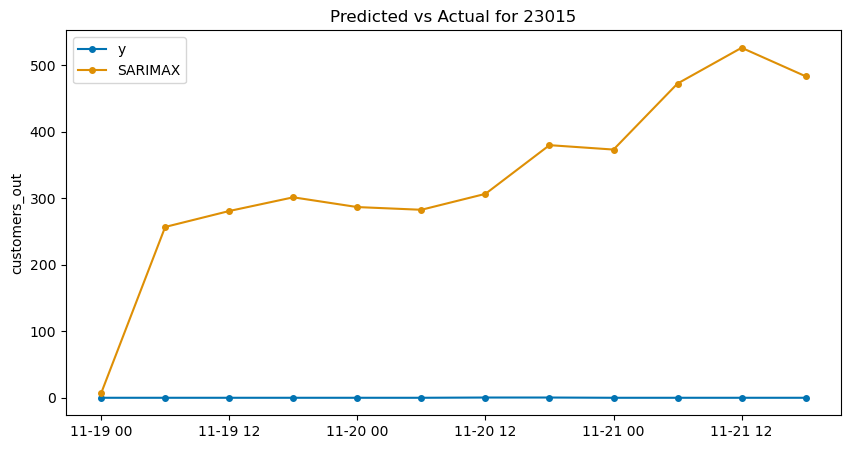

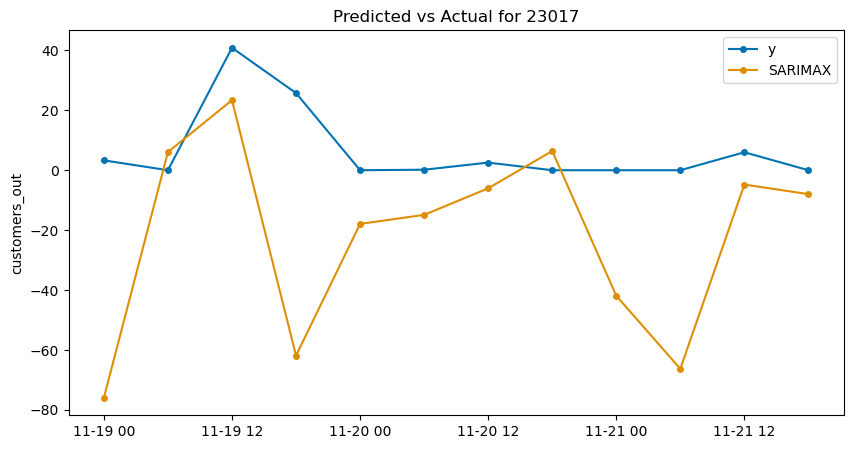

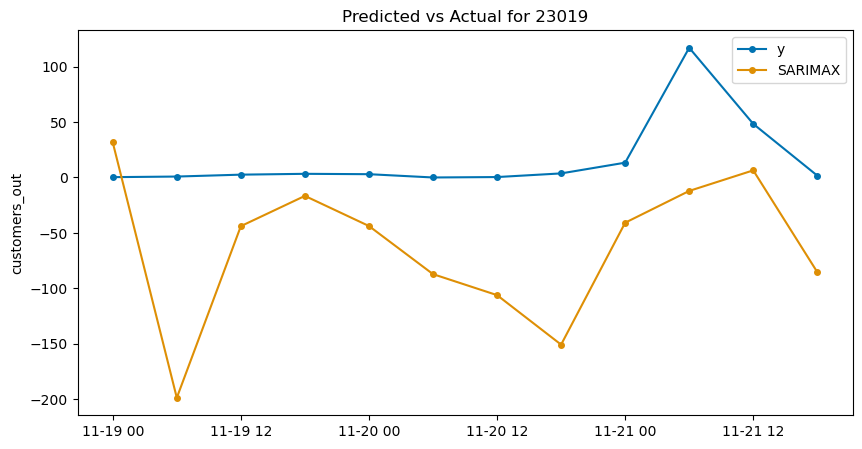

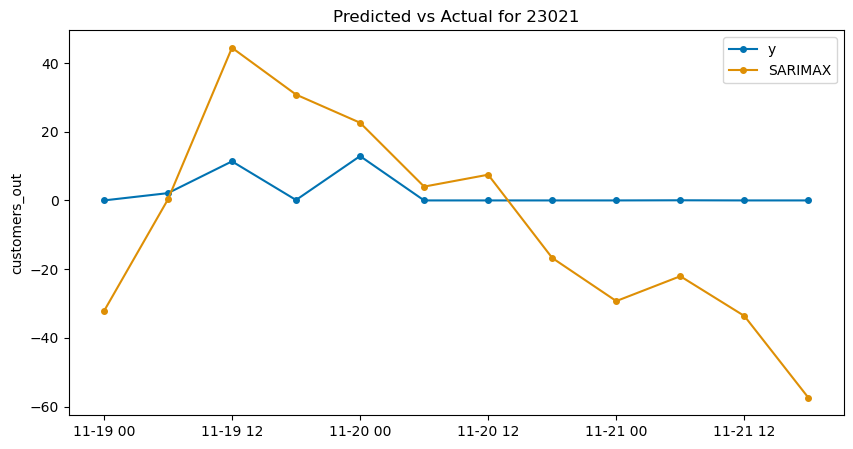

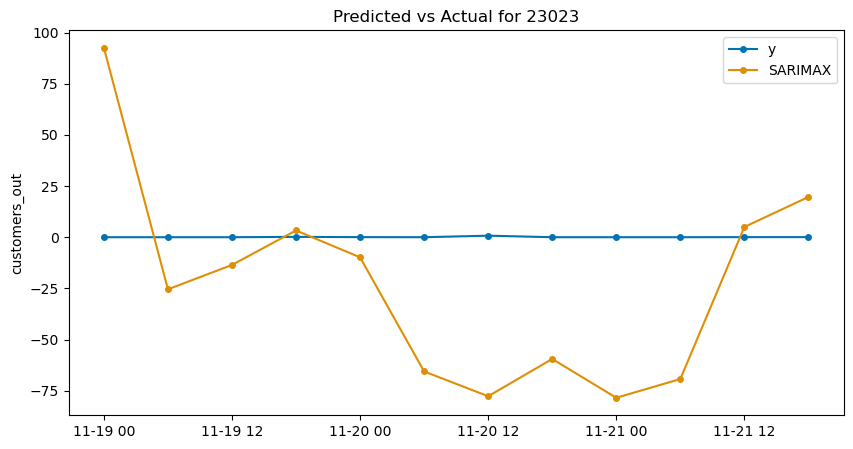

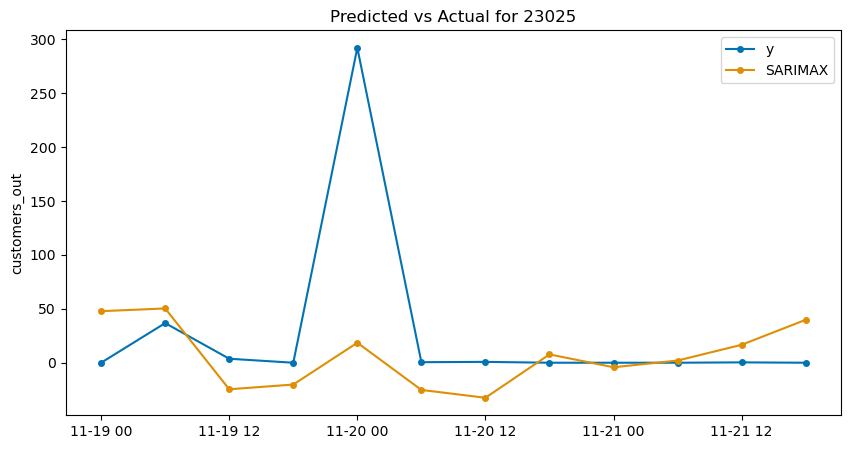

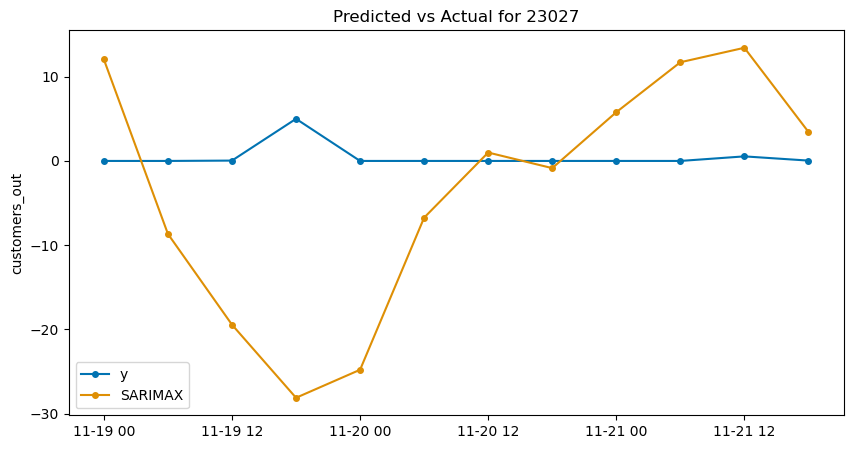

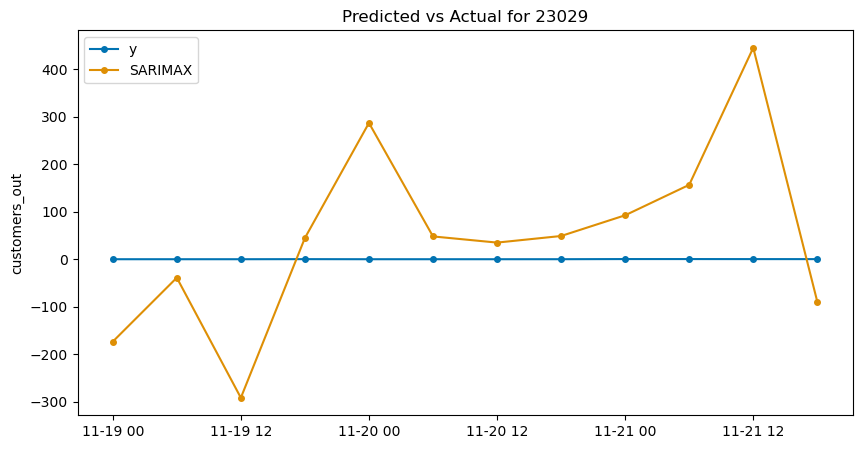

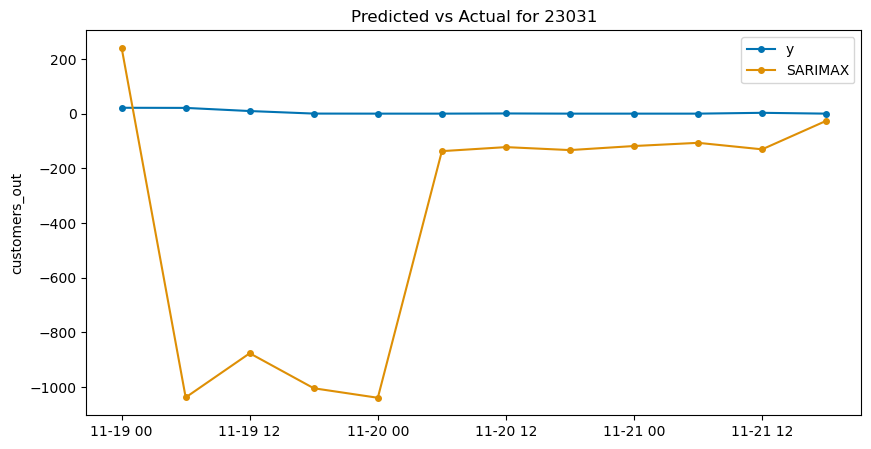

In [30]:
# Make a plot of results.y_test[0] and results.y_pred[0] for each value of fips_code
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = results.y_test[0].loc[fips_code]
    y_pred_fips = results.y_pred[0].loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_fips, labels=["y", "SARIMAX"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

### Evaluate performance

Not so hot!

In [31]:
results.test_MeanSquaredError

0      139.239788
1      132.221852
2      122.106011
3      131.080580
4      120.355363
          ...    
156    166.696610
157    168.356267
158    171.312138
159    167.255144
160    119.249805
Name: test_MeanSquaredError, Length: 161, dtype: float64

### Try it manually

For some reason getting worse predictions when doing it manually...?

In [29]:
# Set up the SARIMAX forecaster with order 5 and no seasonality
forecaster_sarimax =SARIMAX(order=(5, 1, 0), seasonal_order=(0, 0, 0, 0), enforce_stationarity=False, enforce_invertibility=False)

pipe_X = ForecastingPipeline(steps=[
    ("scaler", TabularToSeriesAdaptor(StandardScaler())),
    ("forecaster", forecaster_sarimax),
])
# Let y_small and X_small be the most recent 200 observations of y and X for each value of fips_code
y_small = y.groupby(level=0).tail(200)
X_small = X.groupby(level=0).tail(200)

# Define the SlidingWindowSplitter
sw = SlidingWindowSplitter(
    window_length=28,       # Length of the training window
    fh = np.arange(1,13),   # Forecasting horizon
    step_length=1)          # Step length between windows

#Use sw to make predictions for y_small
mse = MeanSquaredError(square_root = True)
fh = np.arange(1, 13)


results = []
i=0
# Note that sw.split(y_small) creates an array of arrays of (groups of) indices (orgahnized by the hierarchical structure)
# With the splitter specified above, the first value of test would be the array [28..39 228..239 ...]
# that is, the indices for the first 12-values (starting at 29 for the first county, 228 for the second county, etc.)
# We can find the corresponding customers_out values by using y_small.iloc[train_idx]
for train_idx, test_idx in sw.split(y_small):
    # Split the data
    y_small_train, y_small_test, X_small_train, X_small_test = y_small.iloc[train_idx], y_small.iloc[test_idx], X_small.iloc[train_idx], X_small.iloc[test_idx]
    
    # Fit the model
    pipe_X.fit(y_small_train, X_small_train)
    
    # Predict
    y_small_pred = pipe_X.predict(X=X_small_test, fh=sw.fh)
    
    # Calculate performance metric
    rmse = mse(y_small_test, y_small_pred)
    
    # Store the results
    results.append((i, rmse))
    i=i+1

for i, rmse in results:
    print('Iteration', i, f"RMSE: {rmse}")
    #print("-" * 50)

/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

Iteration 0 RMSE: 299.31427508234583
Iteration 1 RMSE: 317.8561128179166
Iteration 2 RMSE: 356.3052521800205
Iteration 3 RMSE: 312.31293946927303
Iteration 4 RMSE: 296.55141575122826
Iteration 5 RMSE: 259.8027661263928
Iteration 6 RMSE: 208.61444945459058
Iteration 7 RMSE: 268.4590457943587
Iteration 8 RMSE: 248.83243937910487
Iteration 9 RMSE: 310.65985693234734
Iteration 10 RMSE: 196.4099062546902
Iteration 11 RMSE: 196.55463659445724
Iteration 12 RMSE: 185.381597575616
Iteration 13 RMSE: 85.81638958670911
Iteration 14 RMSE: 92.67853846042647
Iteration 15 RMSE: 96.26972447279974
Iteration 16 RMSE: 91.12635913978764
Iteration 17 RMSE: 186.3805402042314
Iteration 18 RMSE: 199.18947210422326
Iteration 19 RMSE: 164.42198354724326
Iteration 20 RMSE: 61.0725319664636
Iteration 21 RMSE: 92.48426394981904
Iteration 22 RMSE: 221.2405414003835
Iteration 23 RMSE: 193.85243872453447
Iteration 24 RMSE: 196.02281037889446
Iteration 25 RMSE: 268.7063168312434
Iteration 26 RMSE: 59052483.687457755
I

/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# XGBoost

### QUESTION: How does the training window relate to the "lags" parameter (etc.)?

Next we'll try the sliding window using the DartsXGBModel

Having trouble with the evaluate function - it's failing with 'VectorizedDF' object has no attribute 'copy'. 
After some manual testing, it looks like the error is stemming from the scoring step.
Seems to stem from the xgb predictor renaming the variable from customers_out to c0.
The (silly?) solution is to rename the customers_out variable in y_test to c0 and then everything seems to work....

In [ ]:
# Initialize the DartsXGBModel
# This is just a guess at what the hyperparameters should be...
dartsxgb = DartsXGBModel(
    lags=12,
    lags_past_covariates=None,
    lags_future_covariates=None,
    output_chunk_length=12,
    kwargs={
        "n_estimators": 100,
        "max_depth": 3,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
    }
)
# Let y_small and X_small be the most recent 200 observations of y and X for each value of fips_code
y_small = y.groupby(level=0).tail(200)
X_small = X.groupby(level=0).tail(200)

#In y_small rename customers_out as c0 for compatibility with the output of the xgb predictor
y_small = y_small.rename(columns={"customers_out": "c0"})

fh = np.arange(1, 13)   #Forecasting horizon - we'll need this later
#fh = ForecastingHorizon(13, is_relative=False)

# Define the SlidingWindowSplitter

###Maybe switch to expanding window splitter
sw = SlidingWindowSplitter(
    window_length=28,       # Length of the training window
    fh = np.arange(1,13),   # Forecasting horizon
    step_length=1)          # Step length between windows

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

results = evaluate(
    forecaster=dartsxgb,
    cv=sw,
    y=y_small,
    X=X_small,             # This works with exogeneous variables; predictions are made using predict/predict_proba, or predict_quantiles depending on scoring
    strategy="refit",  # Options are "update" and "refit" (which will reset and fit forecaster via fit), verses updating forecaster via "update"
    scoring=MeanSquaredError(square_root = True),       # None defaults to MeanAbsolutePercentageError(symmetric=True). Options at: https://www.sktime.net/en/stable/api_reference/performance_metrics.html
    return_data=True,   # True means it returns three pd.Series columns for y_train, y_pred, and y_test
    error_score="raise",
    backend=None       # (default is None) Parallelization backend; runs parallel evaluate if specified and strategy="refit"; recommendation to use "dask" or "loky"
)

results.test_MeanSquaredError

0      37.108553
1      33.445700
2      31.490425
3      38.984745
4      35.926345
         ...    
156    19.667429
157    21.690084
158    19.470123
159     8.054889
160     9.886174
Name: test_MeanSquaredError, Length: 161, dtype: float64

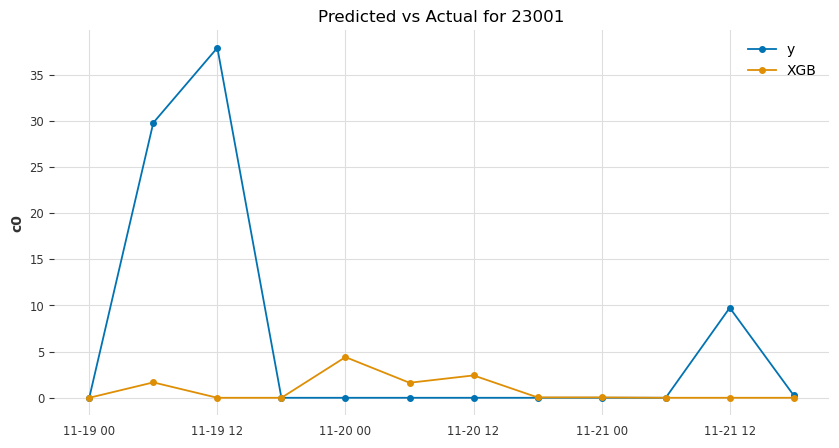

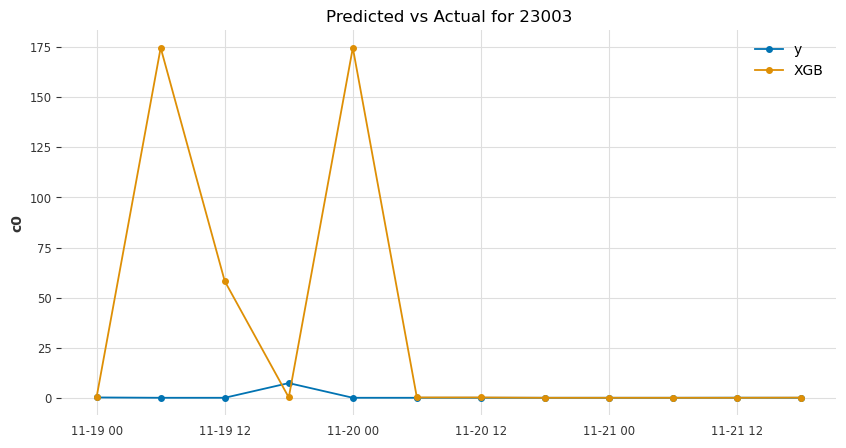

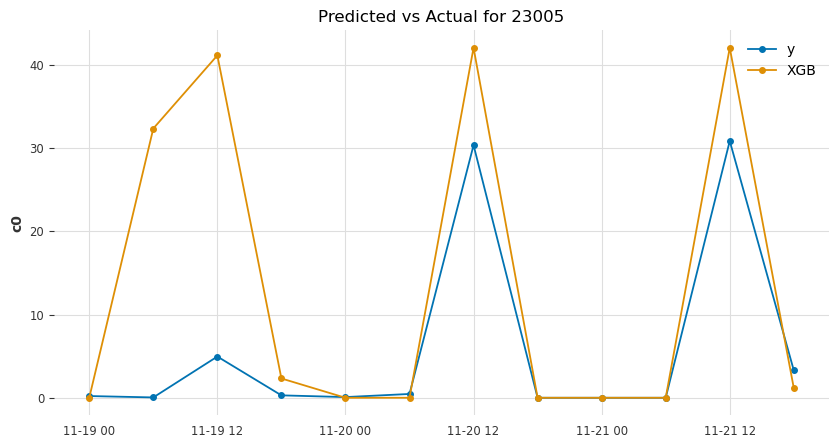

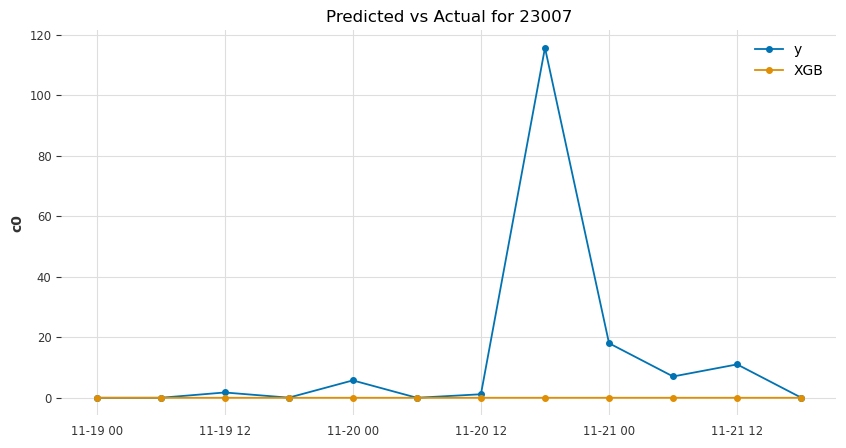

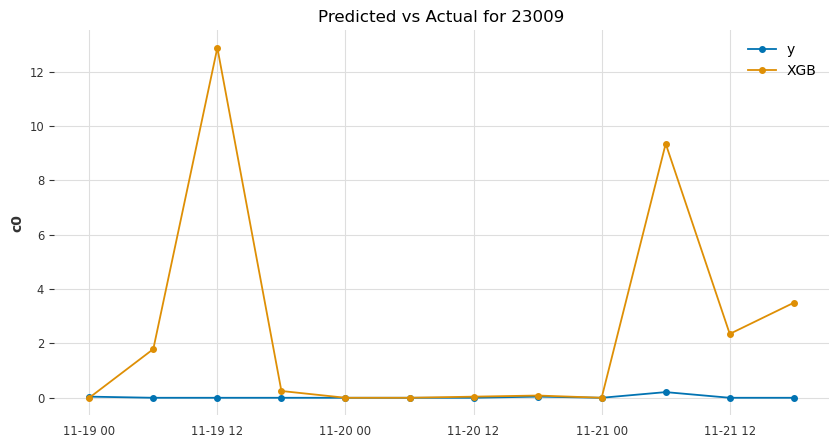

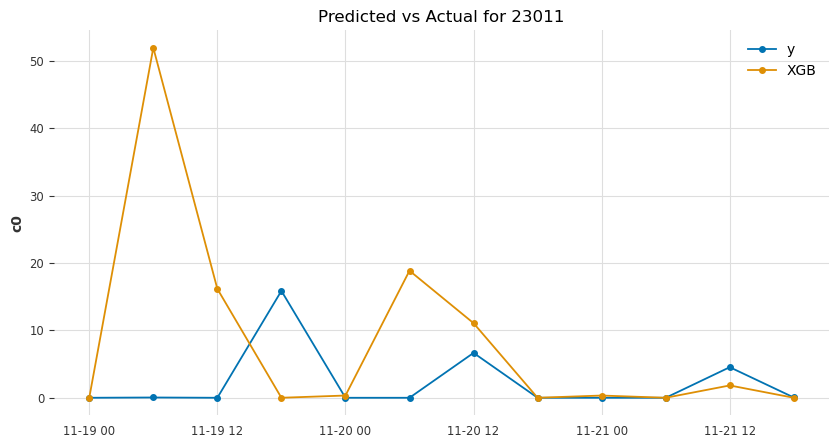

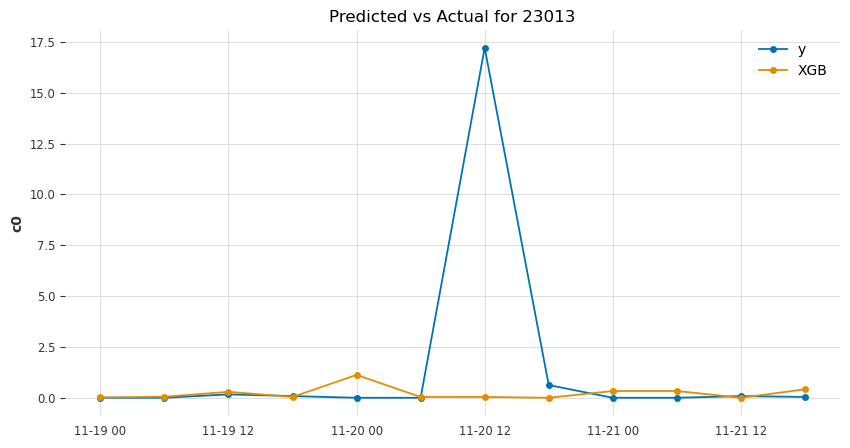

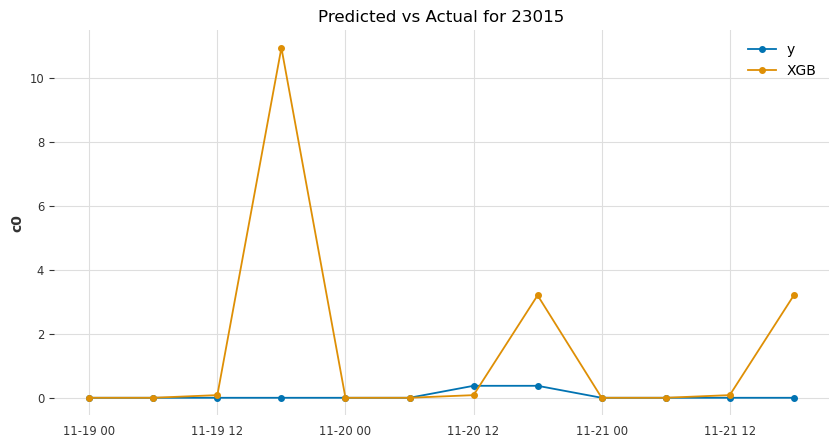

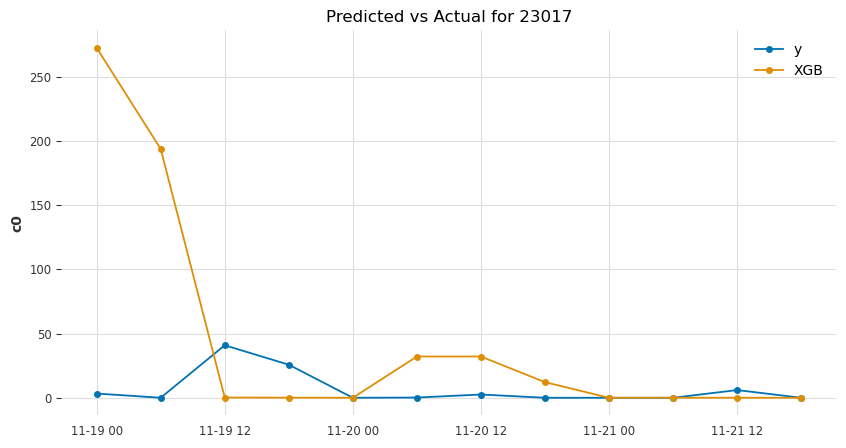

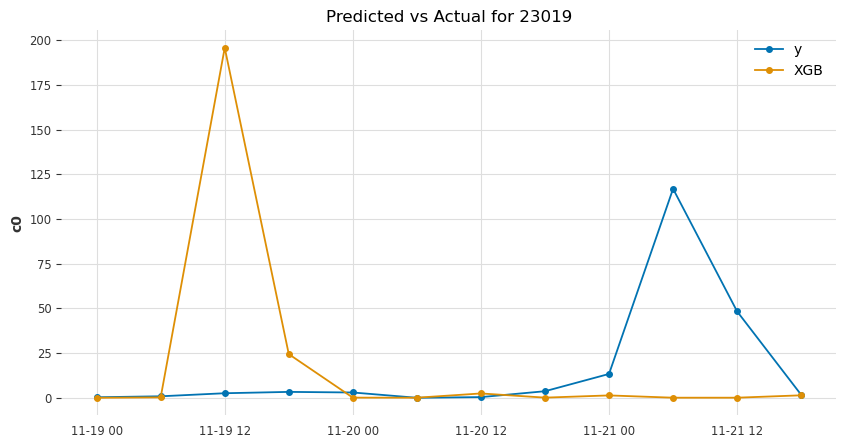

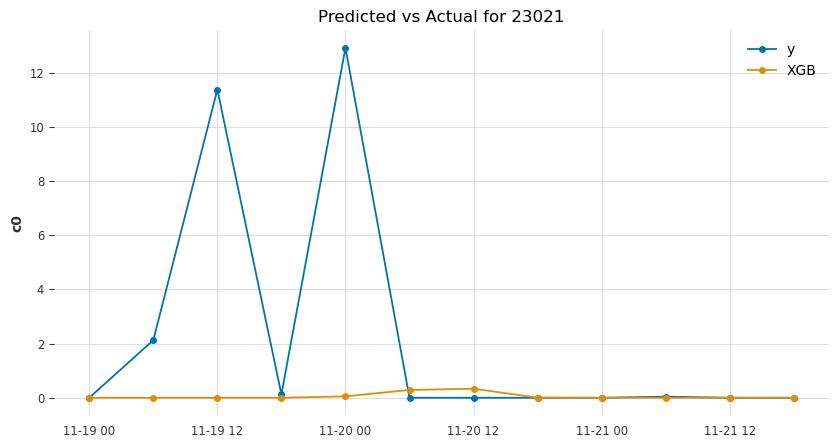

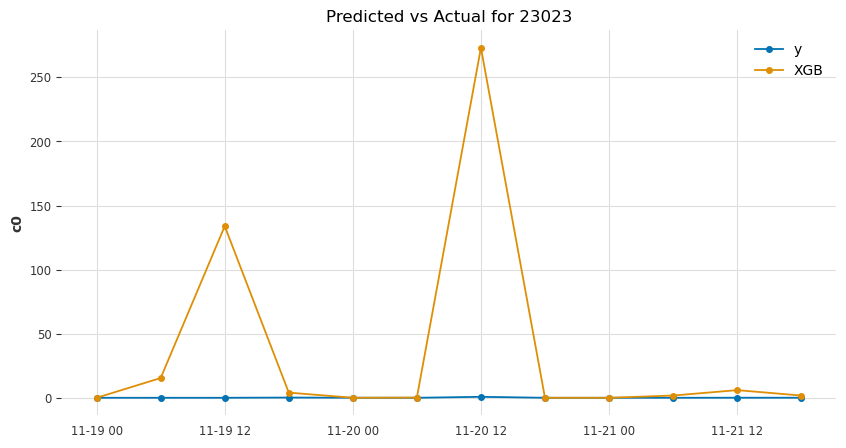

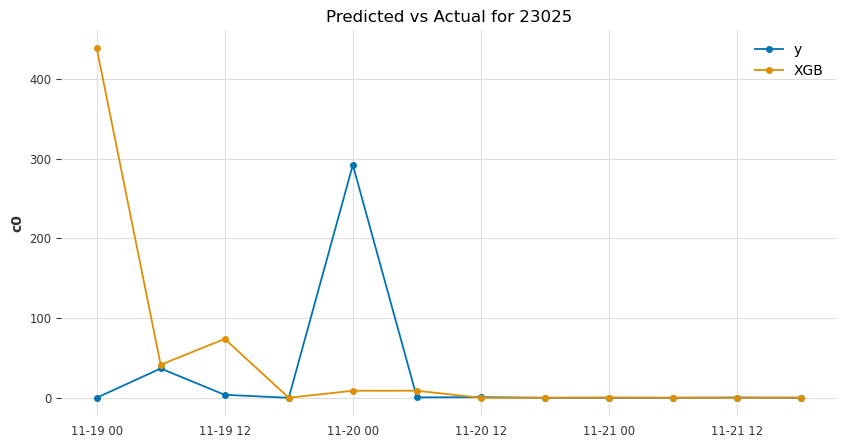

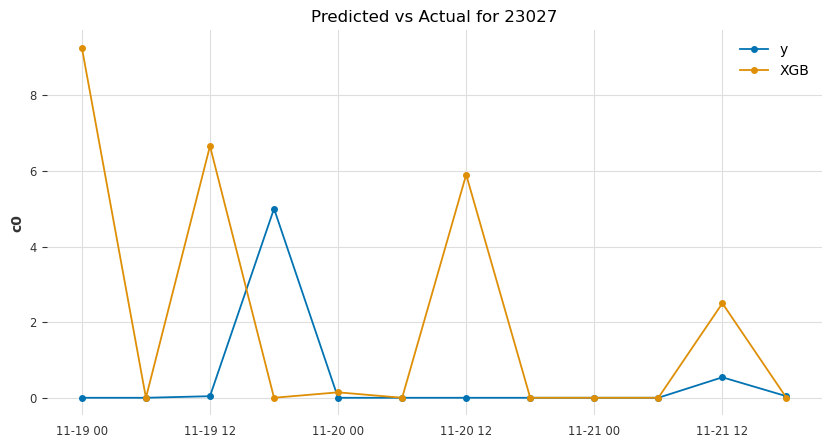

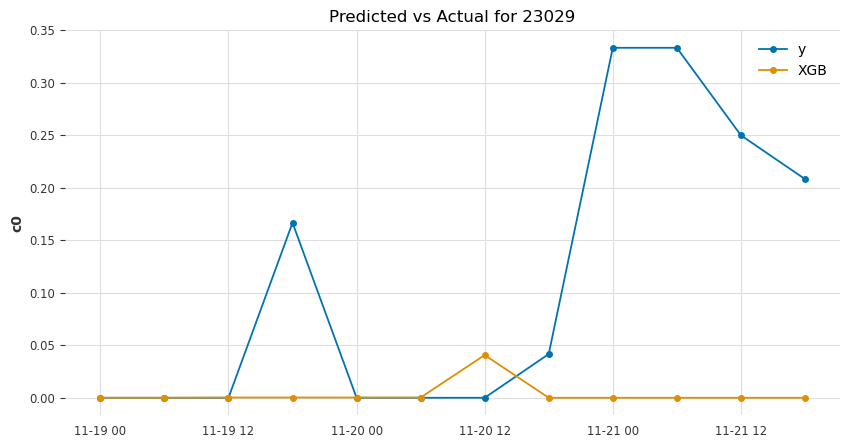

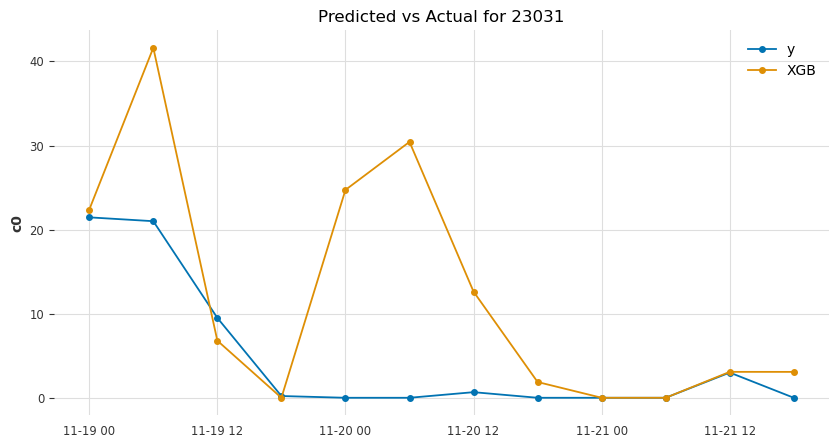

In [60]:
# Make a plot of results.y_test[0] and results.y_pred[0] for each value of fips_code
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = results.y_test[0].loc[fips_code]
    y_pred_fips = results.y_pred[0].loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_fips, labels=["y", "XGB"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

## XGBoost Manually

Note that this takes over 16 minutes to run...

In [56]:
from sklearn.exceptions import DeprecationWarning
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Initialize the DartsXGBModel
# This is just a guess at what the hyperparameters should be...
dartsxgb = DartsXGBModel(
    lags=12,
    lags_past_covariates=None,
    lags_future_covariates=None,
    output_chunk_length=12,
    kwargs={
        "n_estimators": 100,
        "max_depth": 3,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
    }
)
# Let y_small and X_small be the most recent 200 observations of y and X for each value of fips_code
y_small = y.groupby(level=0).tail(200)
X_small = X.groupby(level=0).tail(200)

# Define the SlidingWindowSplitter
sw = SlidingWindowSplitter(
    window_length=28,       # Length of the training window
    fh = np.arange(1,13),   # Forecasting horizon
    step_length=1)          # Step length between windows

#Use sw to make predictions for y_small
mse = MeanSquaredError(square_root = True)
fh = np.arange(1, 13)


results = []
i=0
# Note that sw.split(y_small) creates an array of arrays of (groups of) indices (orgahnized by the hierarchical structure)
# With the splitter specified above, the first value of test would be the array [28..39 228..239 ...]
# that is, the indices for the first 12-values (starting at 29 for the first county, 228 for the second county, etc.)
# We can find the corresponding customers_out values by using y_small.iloc[train_idx]

# Also note that the xgb predictor appears to create a dataset where the predicted variable gets renamed
for train_idx, test_idx in sw.split(y_small):
    # Split the data
    y_small_train, y_small_test, X_small_train, X_small_test = y_small.iloc[train_idx], y_small.iloc[test_idx], X_small.iloc[train_idx], X_small.iloc[test_idx]
    
    # Fit the model
    dartsxgb.fit(y_small_train, X_small_train)
    
    # Predict
    y_small_pred = dartsxgb.predict(X=X_small_test, fh=sw.fh)

    #Convert y_small_test to a (dask?)dataframe
    y_small_test = pd.DataFrame(y_small_test, columns=['customers_out'])
    
    #Convert y_small_pred to a (dask?) dataframe and rename columns so they match
    y_small_pred = pd.DataFrame(y_small_pred, columns=['c0']).rename(columns={'c0': 'customers_out'})

    #print(y_small_test.info())
    #print(y_small_pred.info())

    # Calculate performance metric
    rmse = mse(y_small_test, y_small_pred)
    
    # Store the results
    results.append((i, rmse))
    #results.append((i,0))
    i=i+1

for i, rmse in results:
    print('Iteration', i, f"RMSE: {rmse}")
    #print("-" * 50)

Iteration 0 RMSE: 37.10855254793375
Iteration 1 RMSE: 33.445699938174236
Iteration 2 RMSE: 31.4904246360743
Iteration 3 RMSE: 38.984744615503224
Iteration 4 RMSE: 35.92634511460921
Iteration 5 RMSE: 30.21746313917373
Iteration 6 RMSE: 30.150792956852783
Iteration 7 RMSE: 42.198106631598264
Iteration 8 RMSE: 41.931173178581396
Iteration 9 RMSE: 42.045356470778664
Iteration 10 RMSE: 40.989068290367975
Iteration 11 RMSE: 42.22924030776919
Iteration 12 RMSE: 42.46905066572239
Iteration 13 RMSE: 47.99227021246362
Iteration 14 RMSE: 44.0143374569531
Iteration 15 RMSE: 48.36219036203489
Iteration 16 RMSE: 54.549395914221364
Iteration 17 RMSE: 52.9998902146788
Iteration 18 RMSE: 56.621604179110186
Iteration 19 RMSE: 64.28282045796563
Iteration 20 RMSE: 62.915182982289465
Iteration 21 RMSE: 60.577203402344864
Iteration 22 RMSE: 94.66455738272282
Iteration 23 RMSE: 106.35311920754461
Iteration 24 RMSE: 108.62867678778754
Iteration 25 RMSE: 102.1882435543538
Iteration 26 RMSE: 97.65156177645895
I